# Attention U-Net with binary prompt channel concatenated as a second input channel
A prompt-matched conventional baseline: a binary box prompt is concatenated as an extra image channel (in_channels=2), followed by a plain skip decoder without prompt-conditioned attention (no PSG, no CAD). Gaussian heatmaps remain specific to PGA-UNet.

In [1]:
import os, sys, shutil
import gdown

BASE = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
os.chdir(BASE)

REPO = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_ROOT = f'{BASE}/PGA_Unet2D'
PGA_ROOT = f'{REPO_ROOT}/Source/Prompt-Guided-XRay-Segmentation'
DATASET_NAME = 'dataset_BTXRD'
DATASET_ID = '1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx'
DS_ZIP = f'{BASE}/{DATASET_NAME}.zip'
DS_PATH = f'{PGA_ROOT}/{DATASET_NAME}'

if os.path.exists(REPO_ROOT):
    shutil.rmtree(REPO_ROOT)
!git clone -q --branch main --single-branch {REPO} {REPO_ROOT}
if PGA_ROOT not in sys.path:
    sys.path.insert(0, PGA_ROOT)

if not os.path.exists(DS_ZIP):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}', DS_ZIP, quiet=False)
if os.path.exists(DS_PATH):
    shutil.rmtree(DS_PATH)
!unzip -oq {DS_ZIP} -d {PGA_ROOT}/

os.makedirs(f'{PGA_ROOT}/checkpoints', exist_ok=True)
os.chdir(PGA_ROOT)
!pip install -q tqdm opencv-python timm scipy gdown
print(f'✅ Setup completed | base={BASE} | dataset={DATASET_NAME}')


Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=ba63b04f-c12f-4946-ab5d-00b3aa016109
To: /kaggle/working/dataset_BTXRD.zip
100%|██████████| 1.71G/1.71G [00:26<00:00, 65.5MB/s]


✅ Setup completed | base=/kaggle/working | dataset=dataset_BTXRD


In [2]:
BINARY_PROMPT      = True
VARIANT_NAME       = 'Attention U-Net + prompt channel'


In [3]:
import torch, torch.nn as nn, torch.nn.functional as F
import random
import numpy as np, cv2, json as _json, glob, os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# ── clear module cache then import model ──────────────────────────────────
import sys
sys.path.insert(0, PGA_ROOT)
for _k in list(sys.modules.keys()):
    if 'models' in _k or 'prompt_unet' in _k: del sys.modules[_k]
from models.networks.attunet_concat_prompt import AttUNetConcatPrompt

IMG_SIZE = 512
SCALE_FACTOR     = 3.0
SHIFT_R          = 0.5
MIXED_SHIFT_PROB = 0.8
BATCH    = 4
EPOCHS   = 150
LR       = 1e-4
PATIENCE = 15
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TRAINING_SEED = 22120196
random.seed(TRAINING_SEED)
np.random.seed(TRAINING_SEED)
torch.manual_seed(TRAINING_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAINING_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


from dataset import PromptSegmentationDataset
from torchvision.transforms import InterpolationMode

class BTXRDDataset(PromptSegmentationDataset):
    """Dataset adapter that uses the exact PGA prompt pipeline from dataset.py."""
    def __init__(self, split='test', mode='center_zoom'):
        image_dir = f'{PGA_ROOT}/dataset_BTXRD/{split}/images'
        json_dir = f'{PGA_ROOT}/dataset_BTXRD/{split}/annotations'
        super().__init__(
            image_dir=image_dir,
            json_dir=json_dir,
            img_size=IMG_SIZE,
            is_train=(split == 'train'),
            prompt_mode=mode,
            scale_factor=SCALE_FACTOR,
            shift_ratio=SHIFT_R,
            mixed_shift_prob=0.8,
        )
        # Preserve the metadata interface used by the image-level merge cells.
        self.samples = [
            (os.path.join(image_dir, img_name), shape_idx)
            for img_name, shape_idx in self.all_samples
        ]
        self.prompt_interpolation = cv2.INTER_NEAREST
        self.prompt_augmentation_interpolation = InterpolationMode.NEAREST

    def create_plateau_heatmap(self, bbox, orig_h, orig_w):
        prompt = np.zeros((orig_h, orig_w), dtype=np.float32)
        x_min, y_min, x_max, y_max = bbox
        x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
        x_max, y_max = min(orig_w, int(x_max)), min(orig_h, int(y_max))
        if x_max > x_min and y_max > y_min:
            prompt[y_min:y_max, x_min:x_max] = 1.0
        return prompt

    def __getitem__(self, idx):
        image, mask, prompt = super().__getitem__(idx)
        return image, prompt, mask

def dice_loss(p, t, eps=1e-6):
    p = torch.sigmoid(p)
    i=(p*t).sum(dim=(2,3))
    return (1-(2*i+eps)/(p.sum(dim=(2,3))+t.sum(dim=(2,3))+eps)).mean()
def loss_fn(logit, t): return F.binary_cross_entropy_with_logits(logit,t)+dice_loss(logit,t)

def eval_dice(model, loader):
    """Checkpoint-selection metric: image-level merged Dice, the same rule
    train.py uses (image_level_metrics) and the same rule the File Test cells
    below report. Predictions and GT masks are max-merged per source image
    before Dice so images with several polygons are not over-weighted."""
    model.eval()
    ds = loader.dataset
    single = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    groups = {}
    with torch.no_grad():
        for idx, (img, hm, gt) in enumerate(single):
            img, hm = img.to(DEVICE), hm.to(DEVICE)
            prob = torch.sigmoid(model(img, hm))[0, 0].cpu().numpy()
            g = gt[0, 0].numpy()
            name = ds.all_samples[idx][0]
            if name not in groups:
                groups[name] = [prob.copy(), g.copy()]
            else:
                np.maximum(groups[name][0], prob, out=groups[name][0])
                np.maximum(groups[name][1], g,    out=groups[name][1])
    dices = []
    for prob, g in groups.values():
        p, t = prob > 0.5, g > 0.5
        inter = float((p & t).sum())
        dices.append((2 * inter + 1e-6) / (float(p.sum()) + float(t.sum()) + 1e-6))
    return float(np.mean(dices)) if dices else 0.0

# ── Build model & dataloaders ──────────────────────────────────────────────
model = AttUNetConcatPrompt(in_channels=1, n_classes=1).to(DEVICE)
print(f'Model: {type(model).__name__}  params={sum(p.numel() for p in model.parameters()):,}')
print(f'BINARY_PROMPT={BINARY_PROMPT}  MODEL={type(model).__name__}')

train_dl = DataLoader(BTXRDDataset('train', mode='center_mixed'), BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loaders = {
    'center_zoom': DataLoader(BTXRDDataset('val', mode='center_zoom'), BATCH, shuffle=False, num_workers=2),
    'center_shift': DataLoader(BTXRDDataset('val', mode='center_shift'), BATCH, shuffle=False, num_workers=2),
}

# ── Training loop ──────────────────────────────────────────────────────────
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.5, patience=5)

best_dice, no_imp = 0.0, 0
for ep in range(1, EPOCHS+1):
    model.train(); total=0
    for img,hm,gt in tqdm(train_dl, desc=f'Ep{ep:03d}', leave=True):
        img,hm,gt = img.to(DEVICE),hm.to(DEVICE),gt.to(DEVICE)
        loss = loss_fn(model(img,hm), gt)
        optim.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step(); total += loss.item()
    val_zoom_d = eval_dice(model, val_loaders['center_zoom'])
    val_shift_d = eval_dice(model, val_loaders['center_shift'])
    sched.step(1 - val_shift_d)
    if val_shift_d > best_dice:
        best_dice = val_shift_d
        torch.save(model.state_dict(), 'checkpoints/attunet_concat_binary_prompt_best.pth')
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f'  Early stop @ ep{ep}')
            break
    print(f'  ep{ep:03d}  loss={total/len(train_dl):.4f}  '
          f'val_zoom={val_zoom_d:.4f}  val_shift={val_shift_d:.4f}  '
          f'best_shift={best_dice:.4f}')
print(f'\n✅ Training done. Best center_shift val Dice = {best_dice:.4f}')

# ── Prepare the best checkpoint for the image-level test cells below ────────
# Official test metrics and CSVs are computed only after predictions and GT
# masks have been max-merged by source image. Polygon-level averages are not
# reported because they overweight images that contain multiple polygons.
model.load_state_dict(torch.load('checkpoints/attunet_concat_binary_prompt_best.pth', map_location=DEVICE))
model.eval()
print('Best checkpoint loaded. Continue to the image-level merged test cell below.')


Model: AttUNetConcatPrompt  params=2,466,145
BINARY_PROMPT=True  MODEL=AttUNetConcatPrompt


Ep001: 100%|██████████| 462/462 [01:26<00:00,  5.33it/s]


  ep001  loss=1.5693  val_zoom=0.1537  val_shift=0.1592  best_shift=0.1592


Ep002: 100%|██████████| 462/462 [01:30<00:00,  5.13it/s]


  ep002  loss=1.4489  val_zoom=0.1751  val_shift=0.1739  best_shift=0.1739


...

  ep071  loss=0.2412  val_zoom=0.7919  val_shift=0.7775  best_shift=0.7805


Ep072: 100%|██████████| 462/462 [01:30<00:00,  5.12it/s]


  ep072  loss=0.2351  val_zoom=0.7950  val_shift=0.7754  best_shift=0.7805


Ep073: 100%|██████████| 462/462 [01:30<00:00,  5.11it/s]


  Early stop @ ep73

✅ Training done. Best center_shift val Dice = 0.7805
Best checkpoint loaded. Continue to the image-level merged test cell below.


## File Test - image-level evaluation & balanced visualization

Reuses `model` (already the best checkpoint, `.eval()`) and `BTXRDDataset` defined above: no repo re-clone, no checkpoint re-download, no re-training, the dedicated `attunet_concat_prompt.py` is imported directly from the cloned source. If this errors partway, `checkpoints/attunet_concat_binary_prompt_best.pth` is already saved on disk, so the standalone `File_Test/btxrd/test-pga-vs-attunet-variants-r512-btxrd.ipynb` can still evaluate it without retraining.

In [4]:
# ── File Test: image-level merging (reuses `model` already trained above) ──
import csv
from collections import OrderedDict

os.makedirs('results', exist_ok=True)
model.eval()

def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or  not g.any(): return float(IMG_SIZE)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95), np.percentile(d2,95)))

def calc_metrics_img(prob_np, gt_np):
    pm = (prob_np > 0.5).astype(np.float32)
    gm = (gt_np  > 0.5).astype(np.float32); eps = 1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95 = calc_hd95(pm, gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/(np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps),0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp + eps) / (tp + fp + fn + eps)),
                pre=float(tp / (tp + fp+eps)),          rec=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)


KEYS  = ['dice','iou','pre','rec','hd95','cbl']
HDRS  = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']
MODES = ['center_zoom', 'center_shift']
all_image_records = {}
csv_rows = []

for mode in MODES:
    ds     = BTXRDDataset('test', mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)
    groups = OrderedDict()

    for i, (img_t, hm_t, gt_t) in enumerate(tqdm(loader, desc=f'[{mode}]')):
        img_name  = os.path.basename(ds.samples[i][0])
        gt_np     = gt_t[0, 0].numpy()
        prompt_np = hm_t[0, 0].numpy()
        with torch.no_grad():
            prob = torch.sigmoid(model(img_t.to(DEVICE), hm_t.to(DEVICE)))[0, 0].cpu().numpy()
        if img_name not in groups:
            groups[img_name] = dict(img=img_t[0,0].numpy(), gt_union=gt_np.copy(),
                                    prob_max=prob.copy(), prompts=[prompt_np])
        else:
            np.maximum(groups[img_name]['gt_union'], gt_np,  out=groups[img_name]['gt_union'])
            np.maximum(groups[img_name]['prob_max'], prob,   out=groups[img_name]['prob_max'])
            groups[img_name]['prompts'].append(prompt_np)

    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        m = calc_metrics_img(g['prob_max'], g['gt_union'])
        img_recs.append(dict(img_name=img_name, img=g['img'], gt=g['gt_union'],
                             prob=g['prob_max'], prompts=g['prompts'],
                             n_samples=len(g['prompts']), **m))
    all_image_records[mode] = img_recs
    m_avg  = {k: np.mean([r[k] for r in img_recs]) for k in KEYS}
    n_imgs = len(img_recs); n_samp = sum(r['n_samples'] for r in img_recs)
    csv_rows.append([mode]+[f'{m_avg[k]:.4f}' for k in KEYS]+[str(n_imgs),str(n_samp)])

from IPython.display import display
import pandas as pd

metric_table = pd.DataFrame(csv_rows, columns=['Mode'] + HDRS + ['N_img', 'N_smp'])
display(metric_table.style.set_caption(f'{VARIANT_NAME}: Image-level metrics').hide(axis='index'))

safe_name = VARIANT_NAME.lower().replace(' ','_').replace('—','').replace('(','').replace(')','').replace(',','').strip('_')
with open(f'results/{safe_name}_results.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['mode']+KEYS+['N_img','N_samples']); w.writerows(csv_rows)
print('\n✅ CSV saved')

# ── Per-image CSV (for Wilcoxon statistical testing, Appendix C.1) ─────────────────
with open(f'results/{safe_name}_per_image.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['mode', 'img_name'] + KEYS)
    for mode in MODES:
        for r in all_image_records[mode]:
            w.writerow([mode, r['img_name']] + [f"{r[k]:.6f}" for k in KEYS])
print('✅ CSV per-image saved:', f'results/{safe_name}_per_image.csv')

[center_shift]: 100%|██████████| 232/232 [00:06<00:00, 34.01it/s]


Mode,Dice↑,IoU↑,Prec↑,Rec↑,HD95↓,CBL↑,N_img,N_smp
center_zoom,0.7596,0.6348,0.7339,0.8137,33.0187,0.8954,187,232
center_shift,0.7477,0.6257,0.7413,0.7887,32.5560,0.8897,187,232



✅ CSV saved
✅ CSV per-image saved: results/attention_u-net_+_prompt_channel_per_image.csv


Balanced test stems (10): ['IMG000002.png', 'IMG000006.png', 'IMG000013.png', 'IMG000020.png', 'IMG000028.png', 'IMG000052.png', 'IMG000054.png', 'IMG000066.png', 'IMG000078.png', 'IMG000084.png']


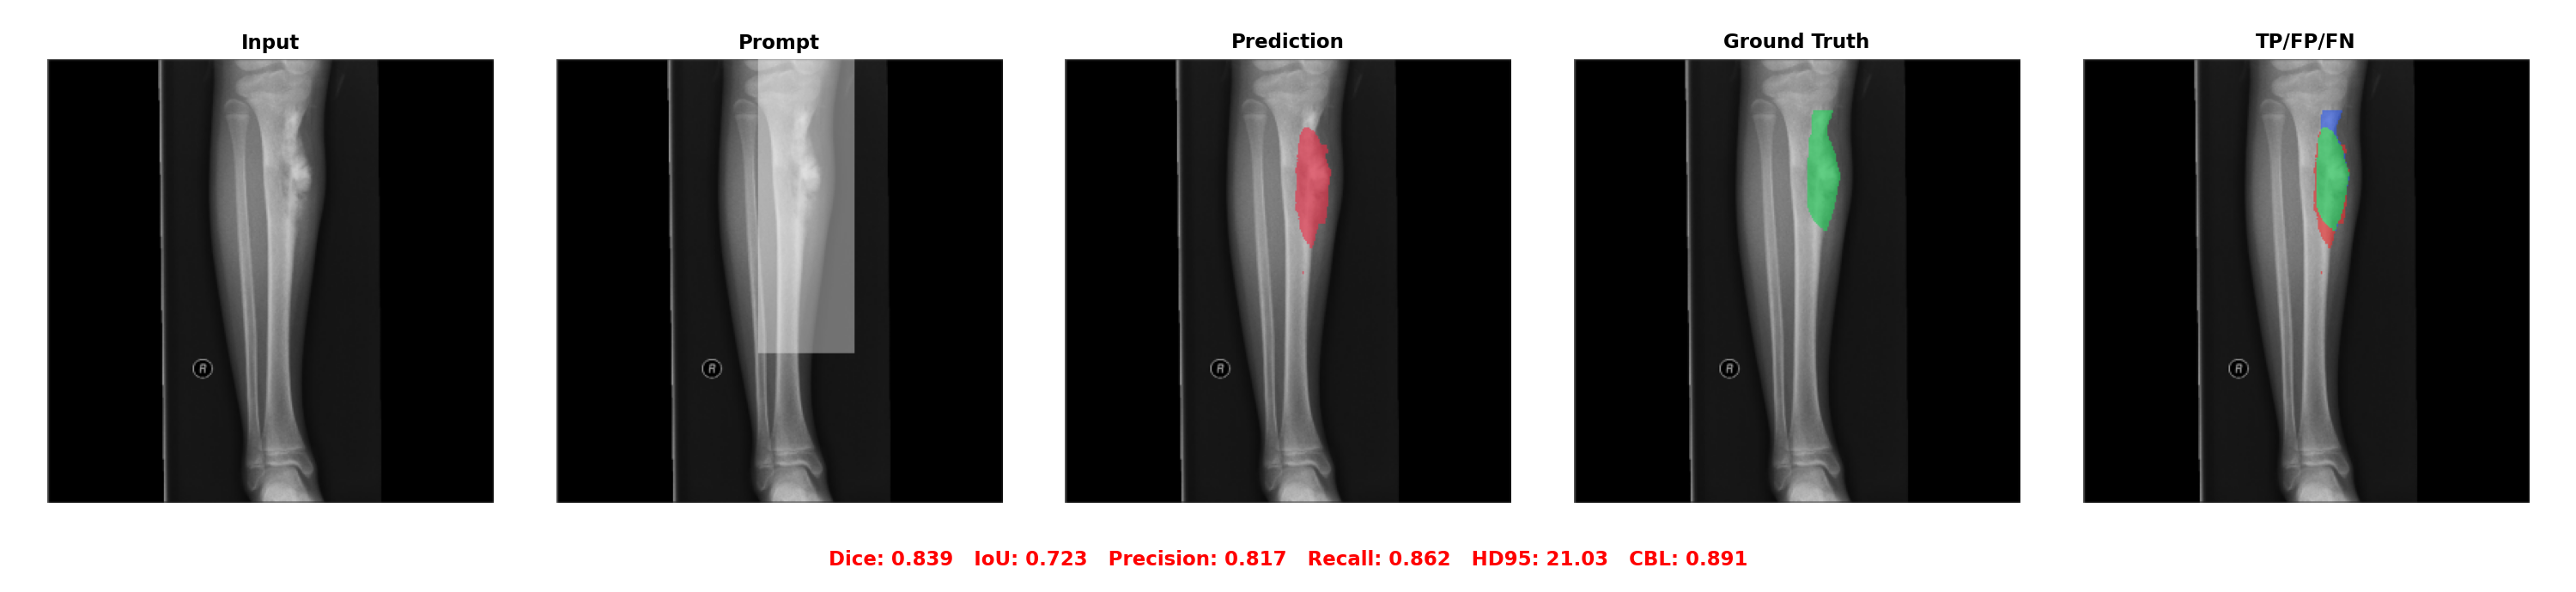

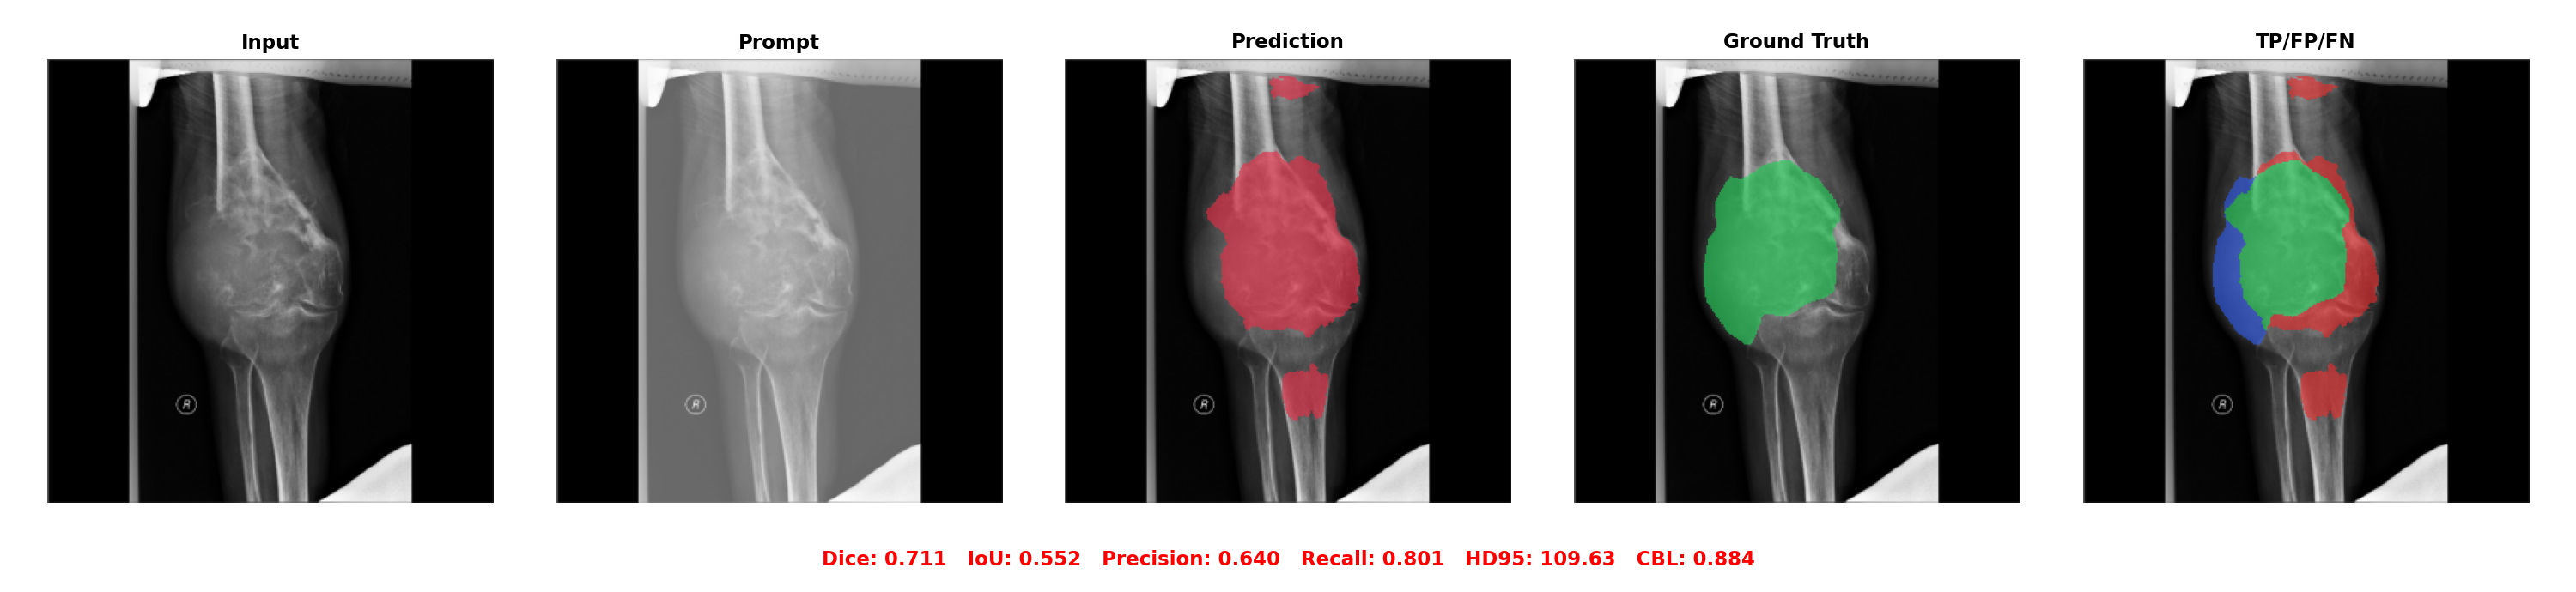

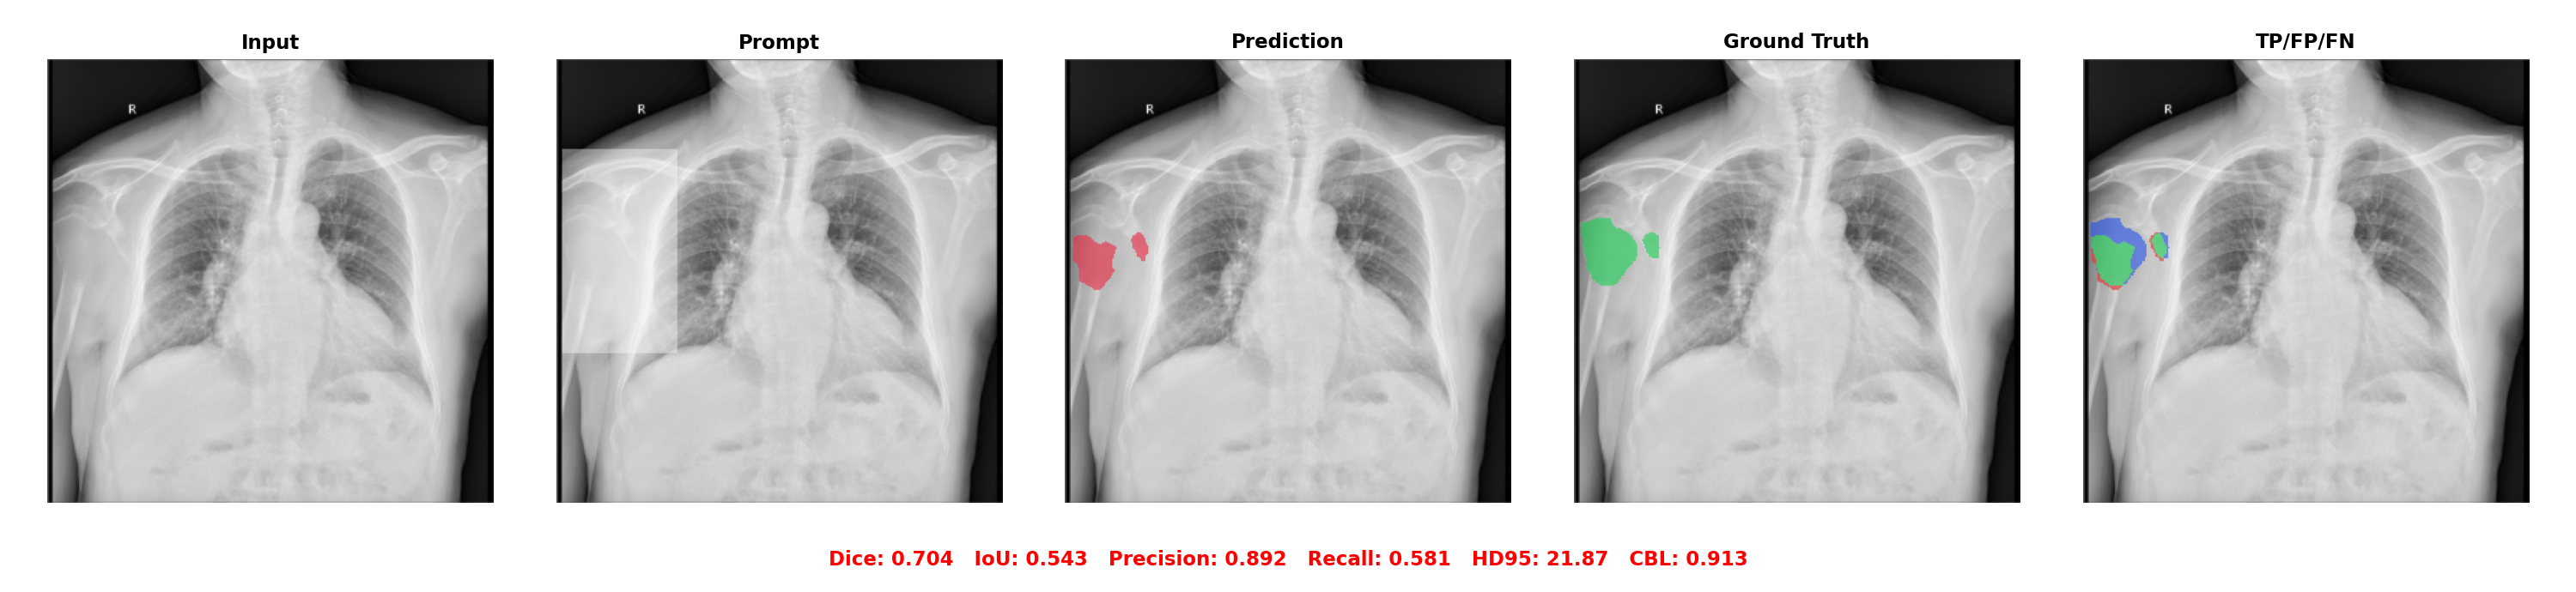

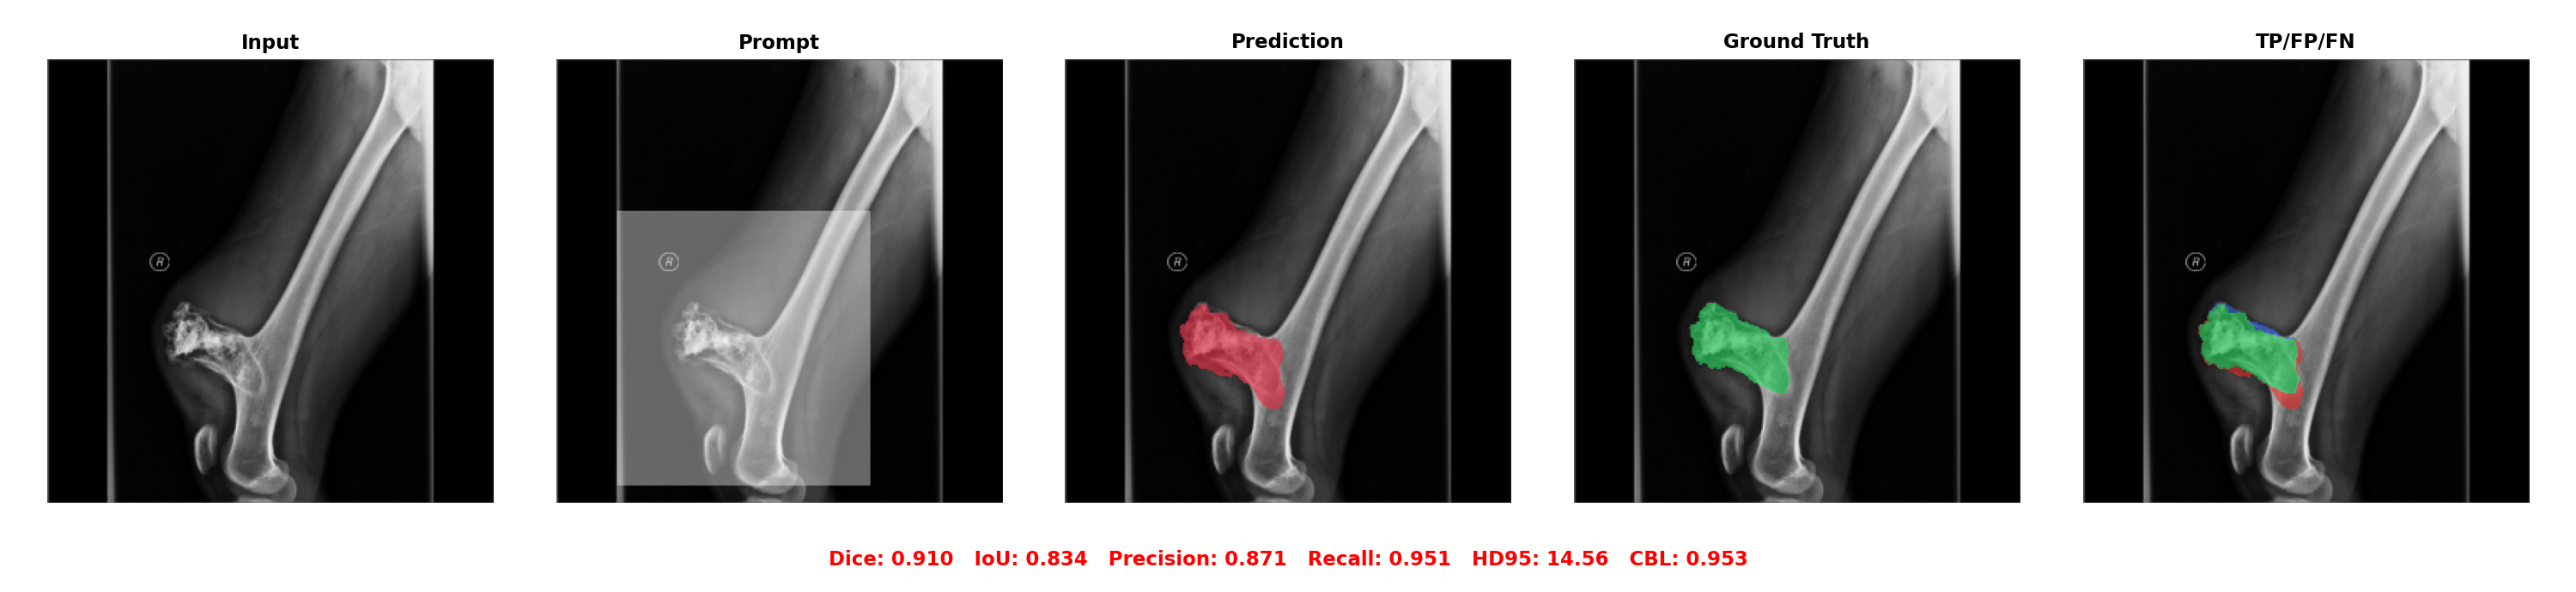

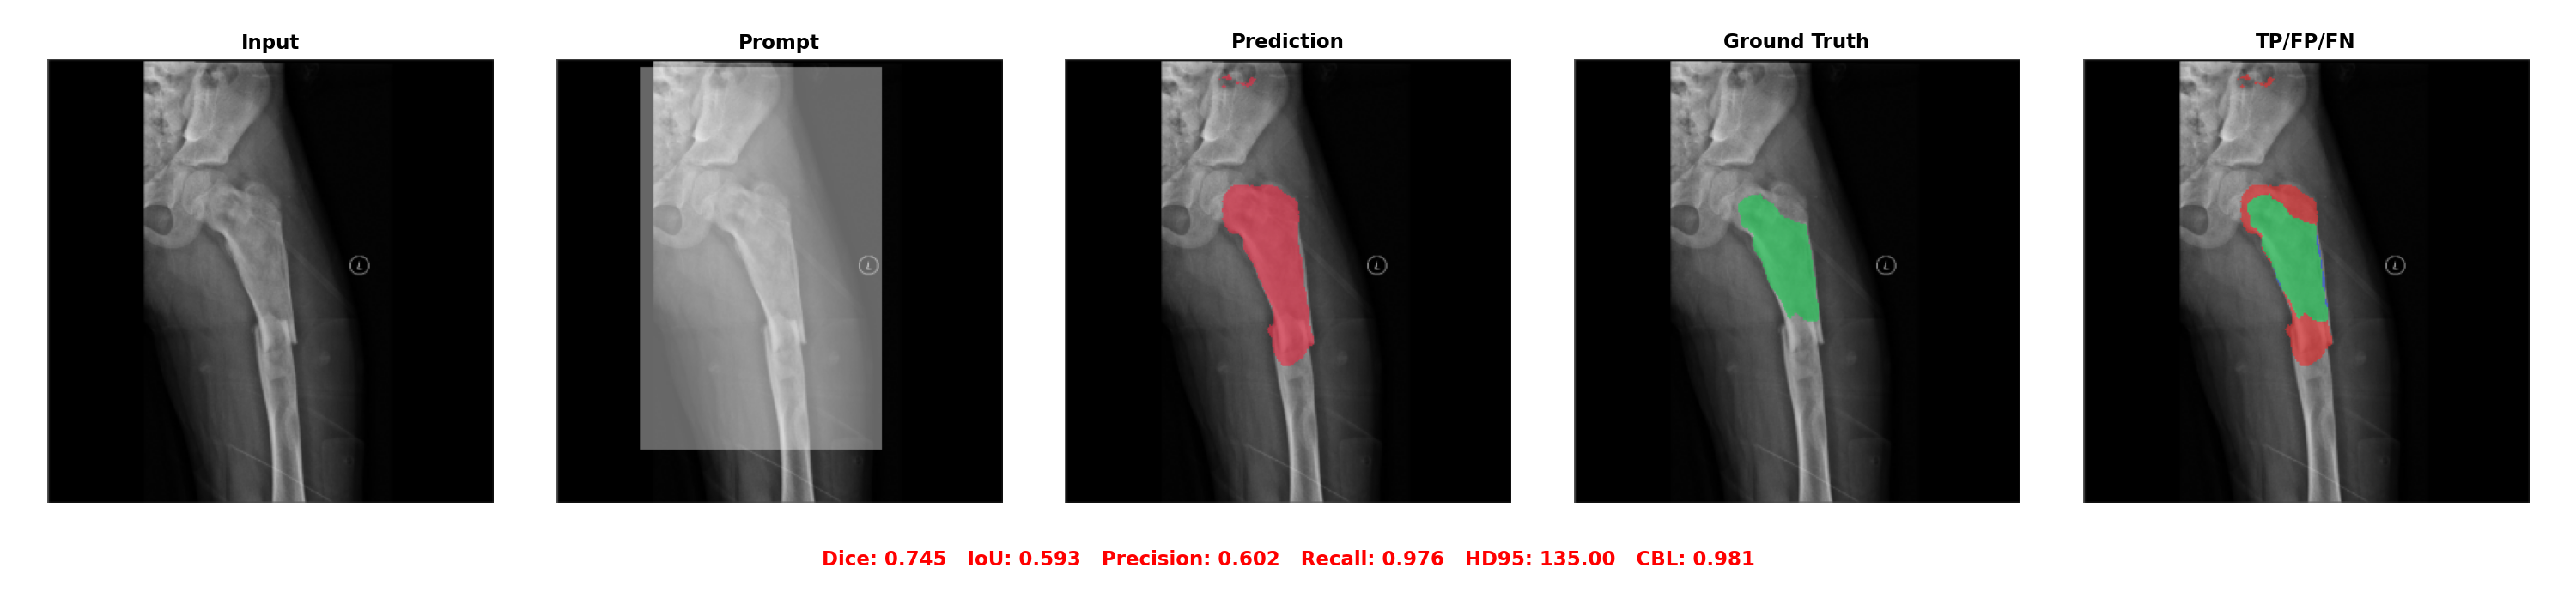

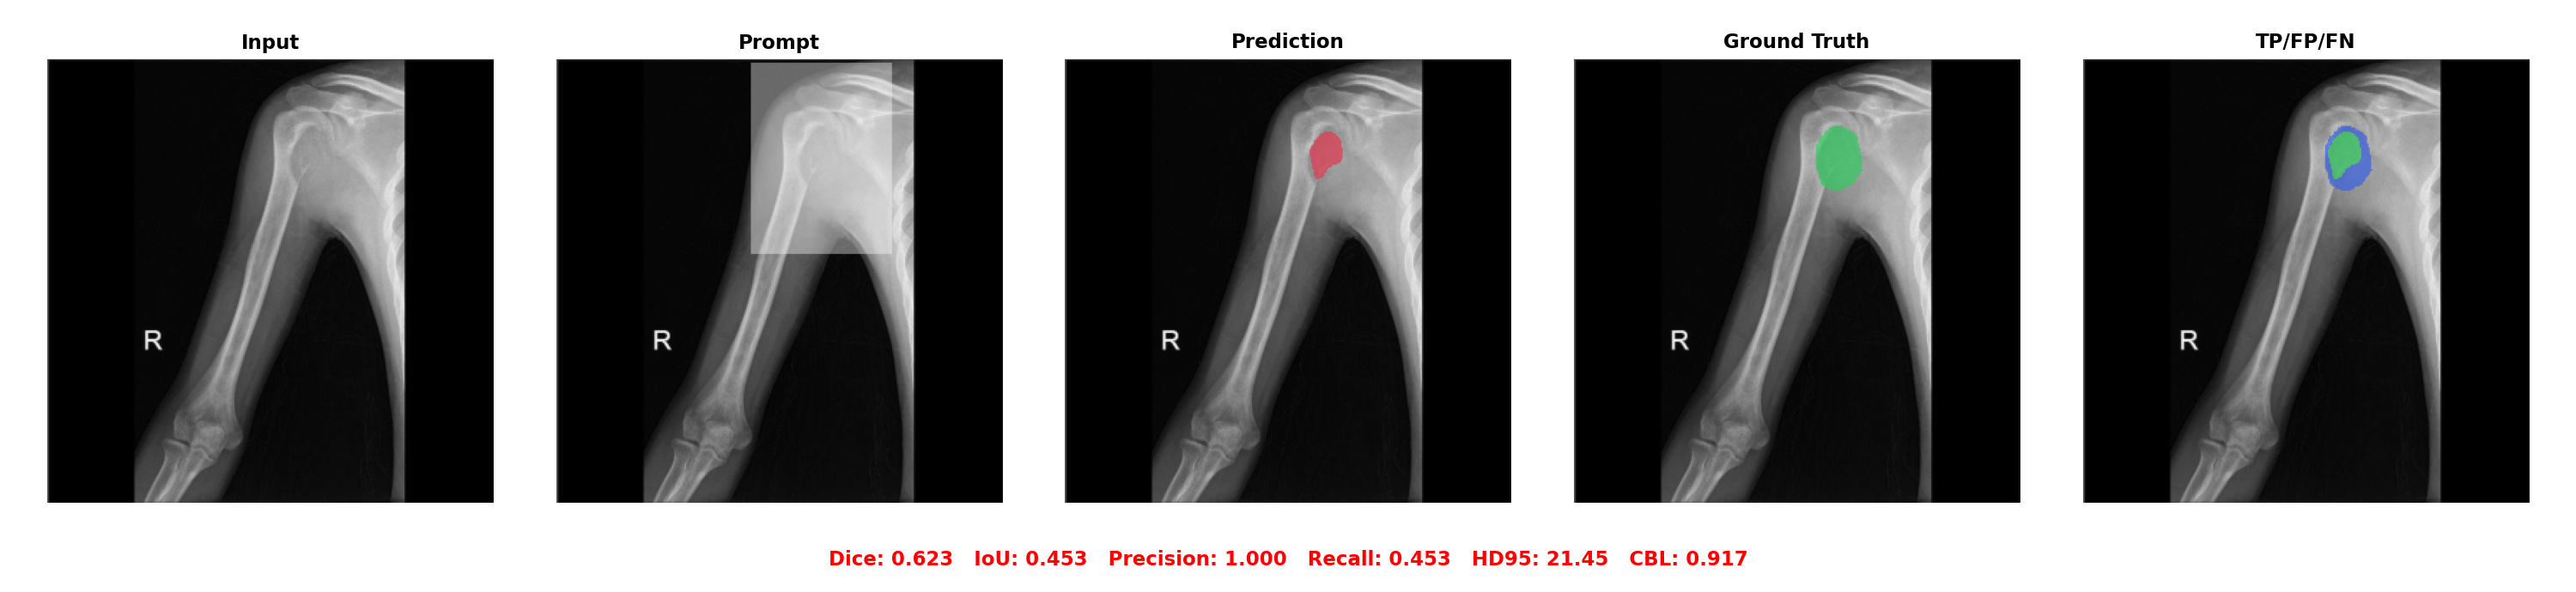

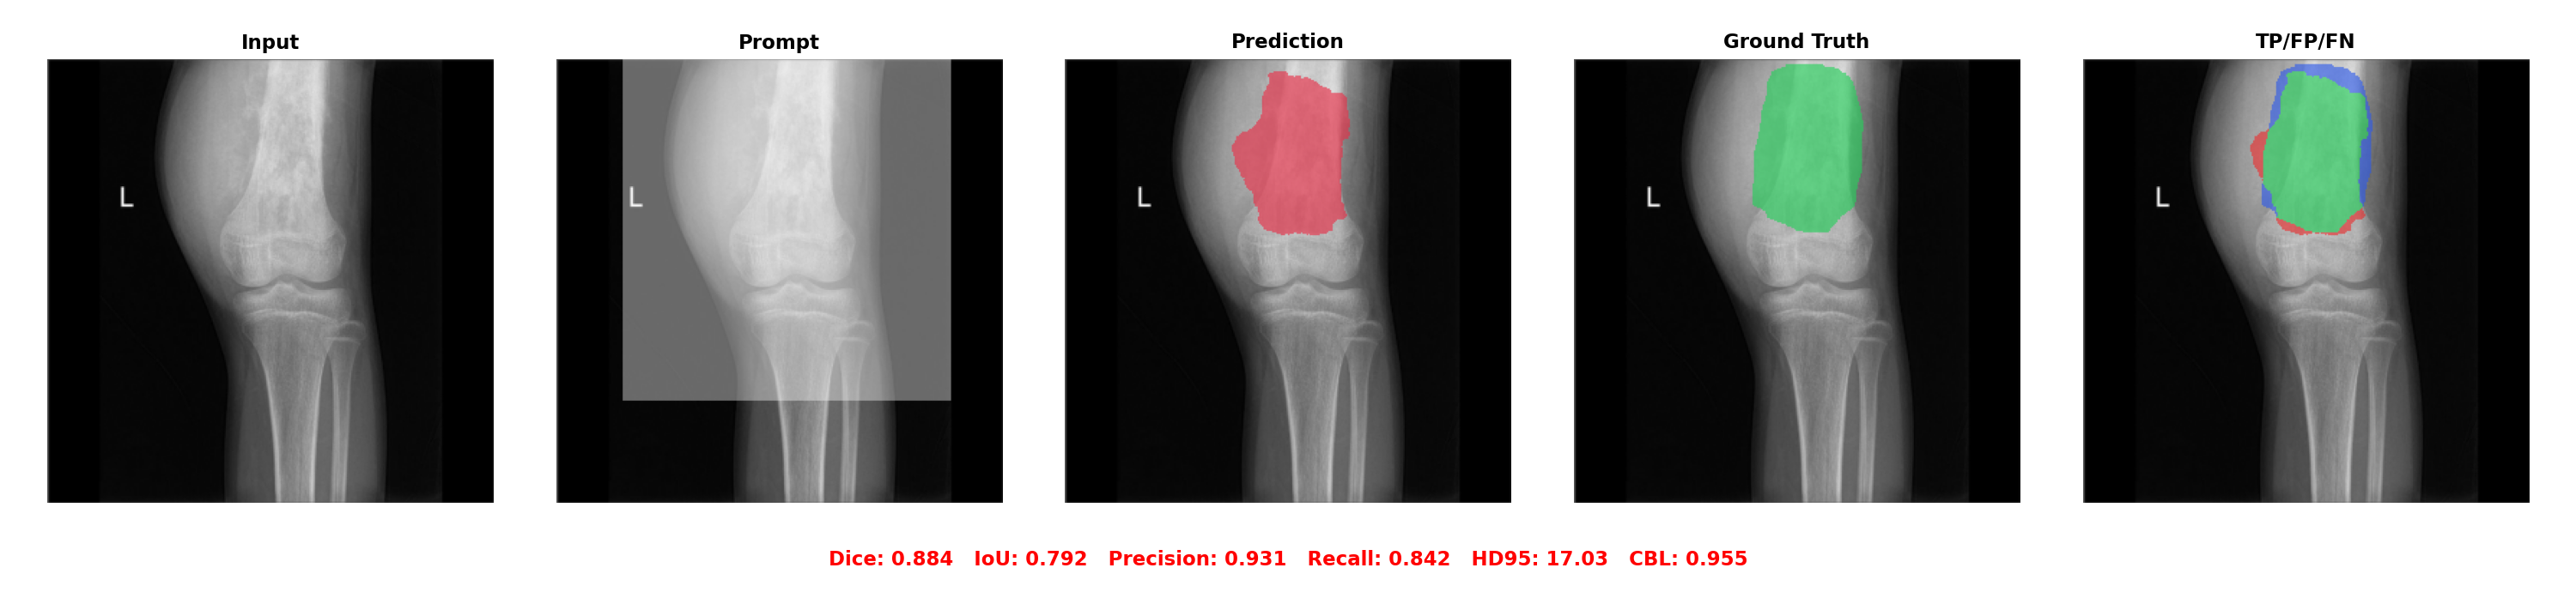

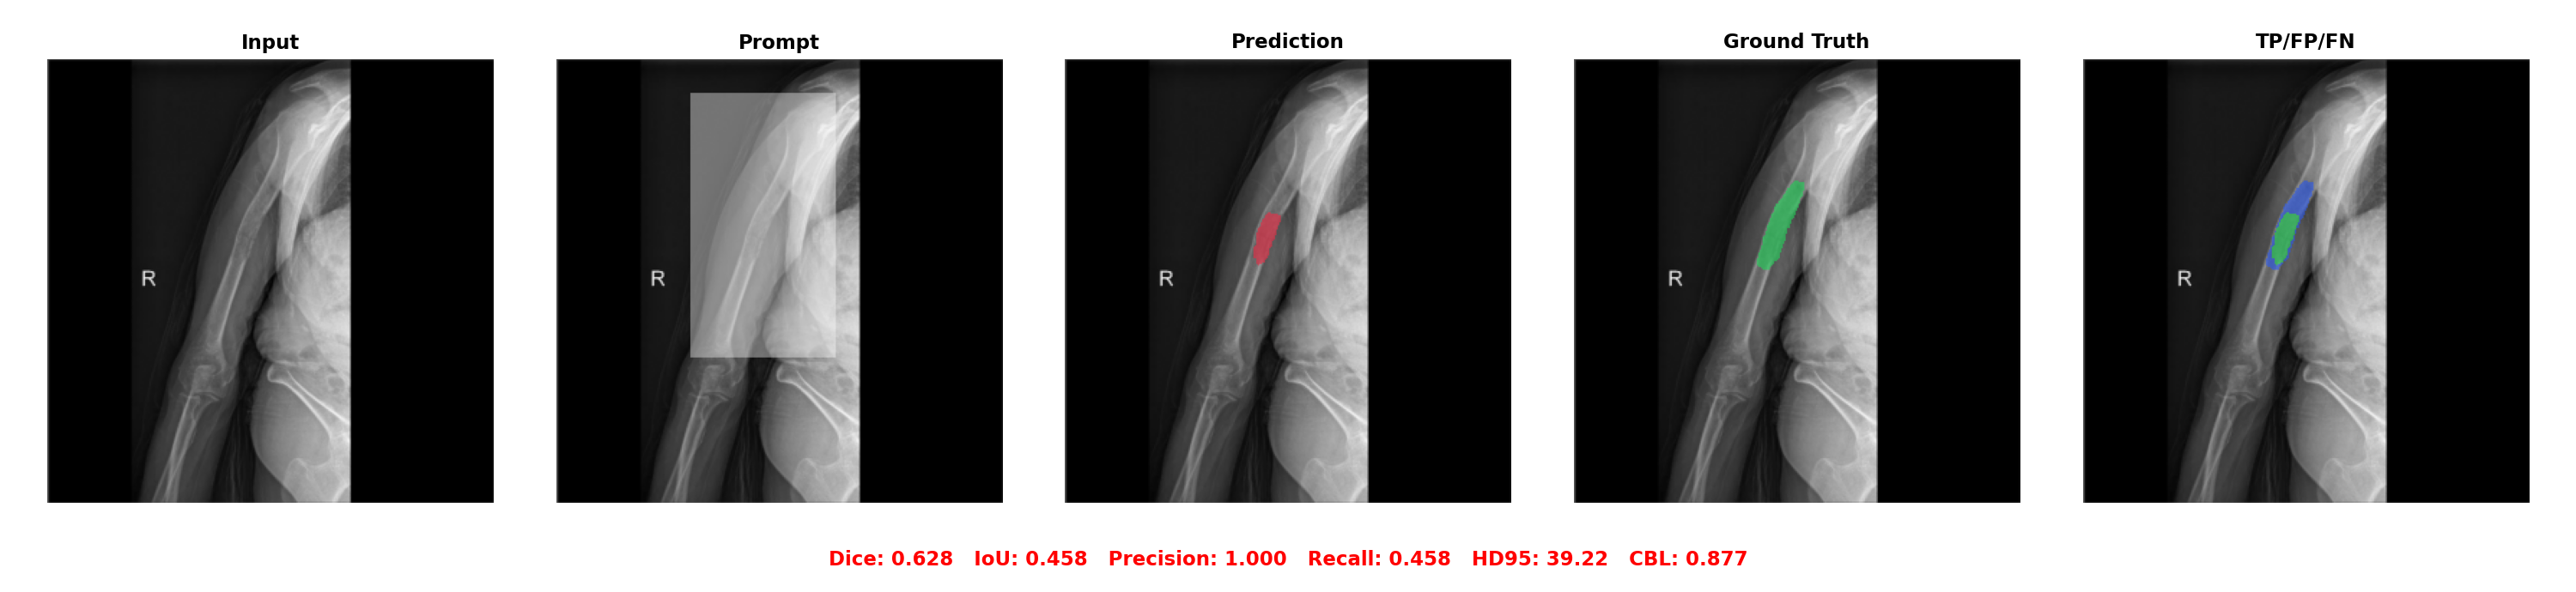

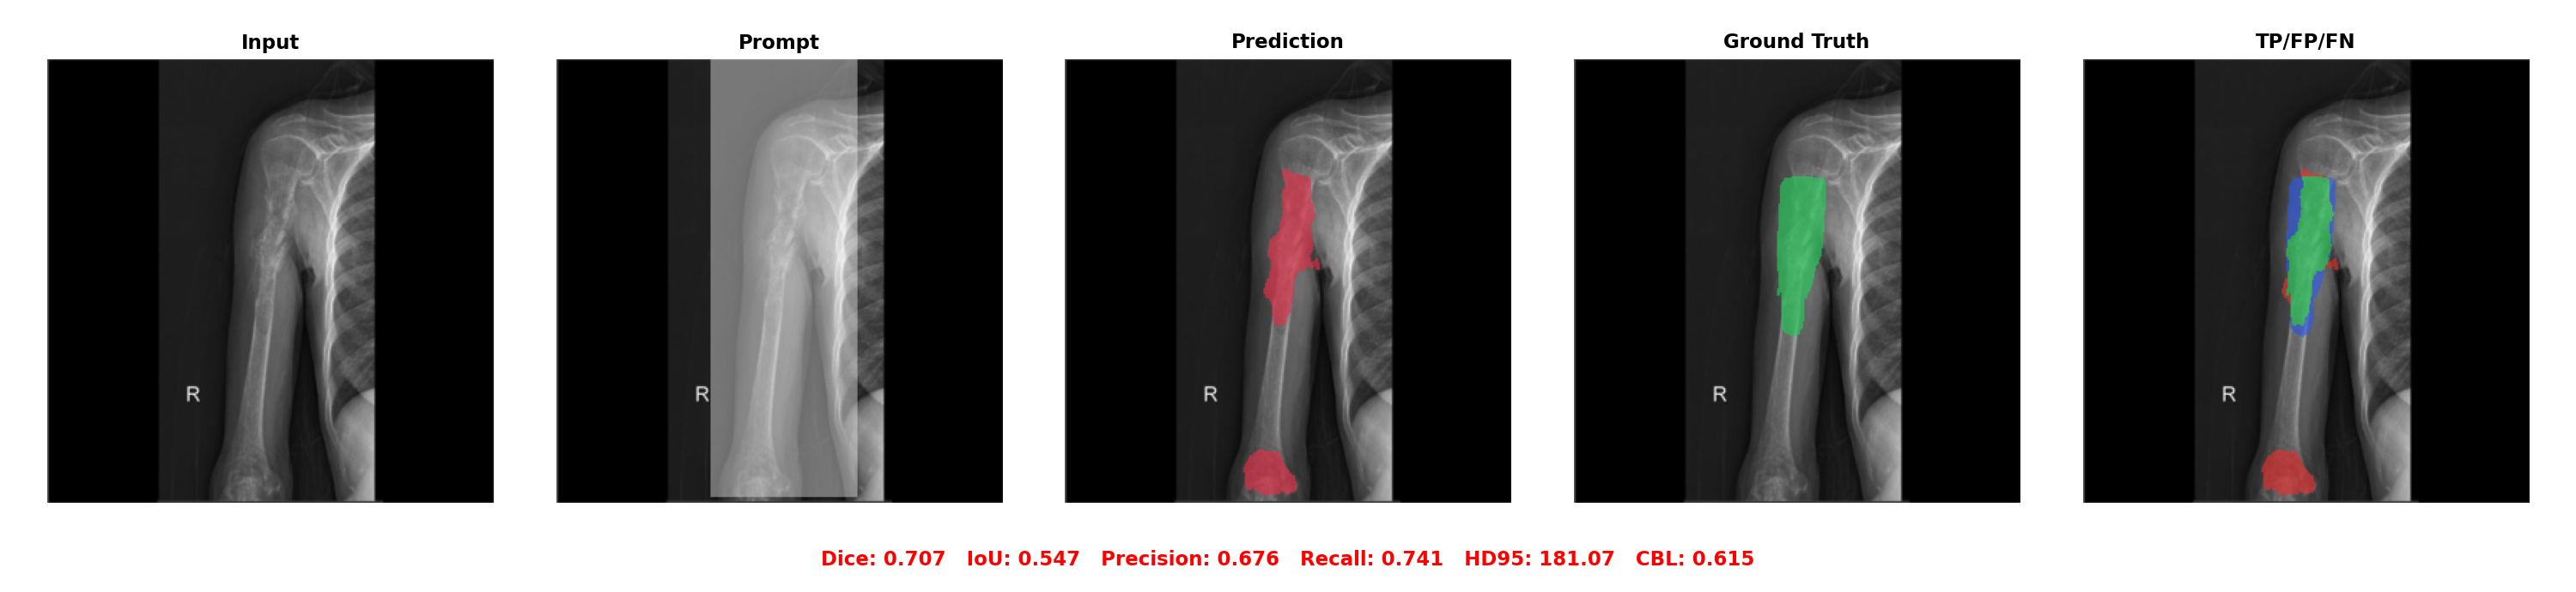

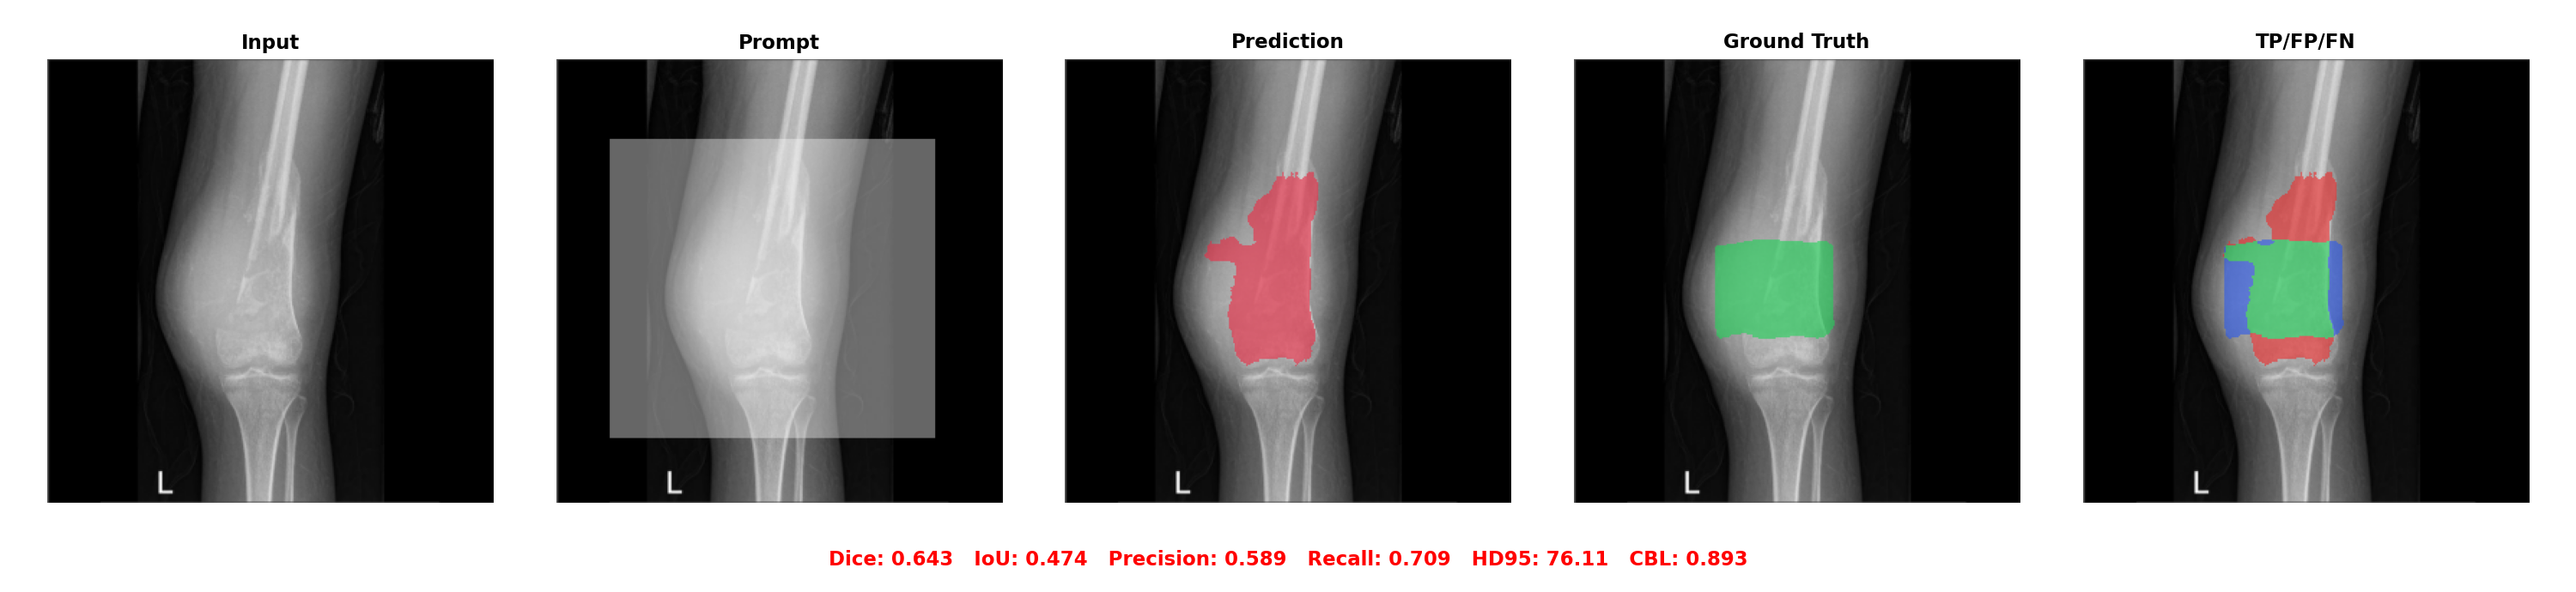

In [5]:
from qualitative_visualization import export_qualitative_rows, select_shared_stems, records_for_stems
# ── File Test: Balanced qualitative visualization (center_zoom, 5 multi-polygon + 5 single-polygon) ──
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the File Test cell first'
N_MULTI = 5
N_SINGLE = 5

TRAIN_SHARED_STEMS = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
recs = records_for_stems(all_image_records['center_zoom'], TRAIN_SHARED_STEMS, context='center_zoom qualitative records')
N_SHOW = len(recs)
print(f'Balanced test stems ({N_SHOW}): {TRAIN_SHARED_STEMS}')

col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for count, rec in enumerate(recs):
    img_np = rec['img'] * 0.5 + 0.5
    gt_np = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0) if len(rec['prompts']) else np.zeros_like(gt_np)
    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1 - gt_np)).sum(); fn = ((1 - pred_np) * gt_np).sum(); eps = 1e-6
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec_ = (tp + eps) / (tp + fn + eps)

    fig, row = plt.subplots(1, 5, figsize=(20, 4.6), squeeze=False)
    row = row[0]
    fig.suptitle(f'{VARIANT_NAME} | center_zoom | {rec["img_name"]}', fontsize=13, fontweight='bold', y=0.995)
    for panel_ax, column_title in zip(row, col_titles):
        panel_ax.set_title(column_title, fontsize=10, fontweight='bold')
    bg = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{rec["n_samples"]}p]\nDice={dice:.3f}', fontsize=8)
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged > 0, prompt_merged, np.nan), cmap='gray', alpha=0.40, vmin=0, vmax=1)
    row[2].imshow(bg); row[2].imshow(pred_np, cmap='Blues', alpha=0.60 * pred_np, vmin=0, vmax=1)
    row[3].imshow(bg); row[3].imshow(gt_np, cmap='Greens', alpha=0.60 * gt_np, vmin=0, vmax=1)
    overlay = np.zeros((*gt_np.shape, 3), dtype=float)
    overlay[..., 1] = pred_np * gt_np
    overlay[..., 0] = pred_np * (1 - gt_np)
    overlay[..., 2] = (1 - pred_np) * gt_np
    row[4].imshow(bg); row[4].imshow(overlay, alpha=0.75 * np.any(overlay > 0, axis=-1), vmin=0, vmax=1)
    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))
    plt.tight_layout(rect=[0, 0.13, 1, 0.94])
    export_qualitative_rows(
        fig, row[np.newaxis, :], [rec],
        prefix=f'{safe_name}_center_zoom_{count + 1:02d}',
    )



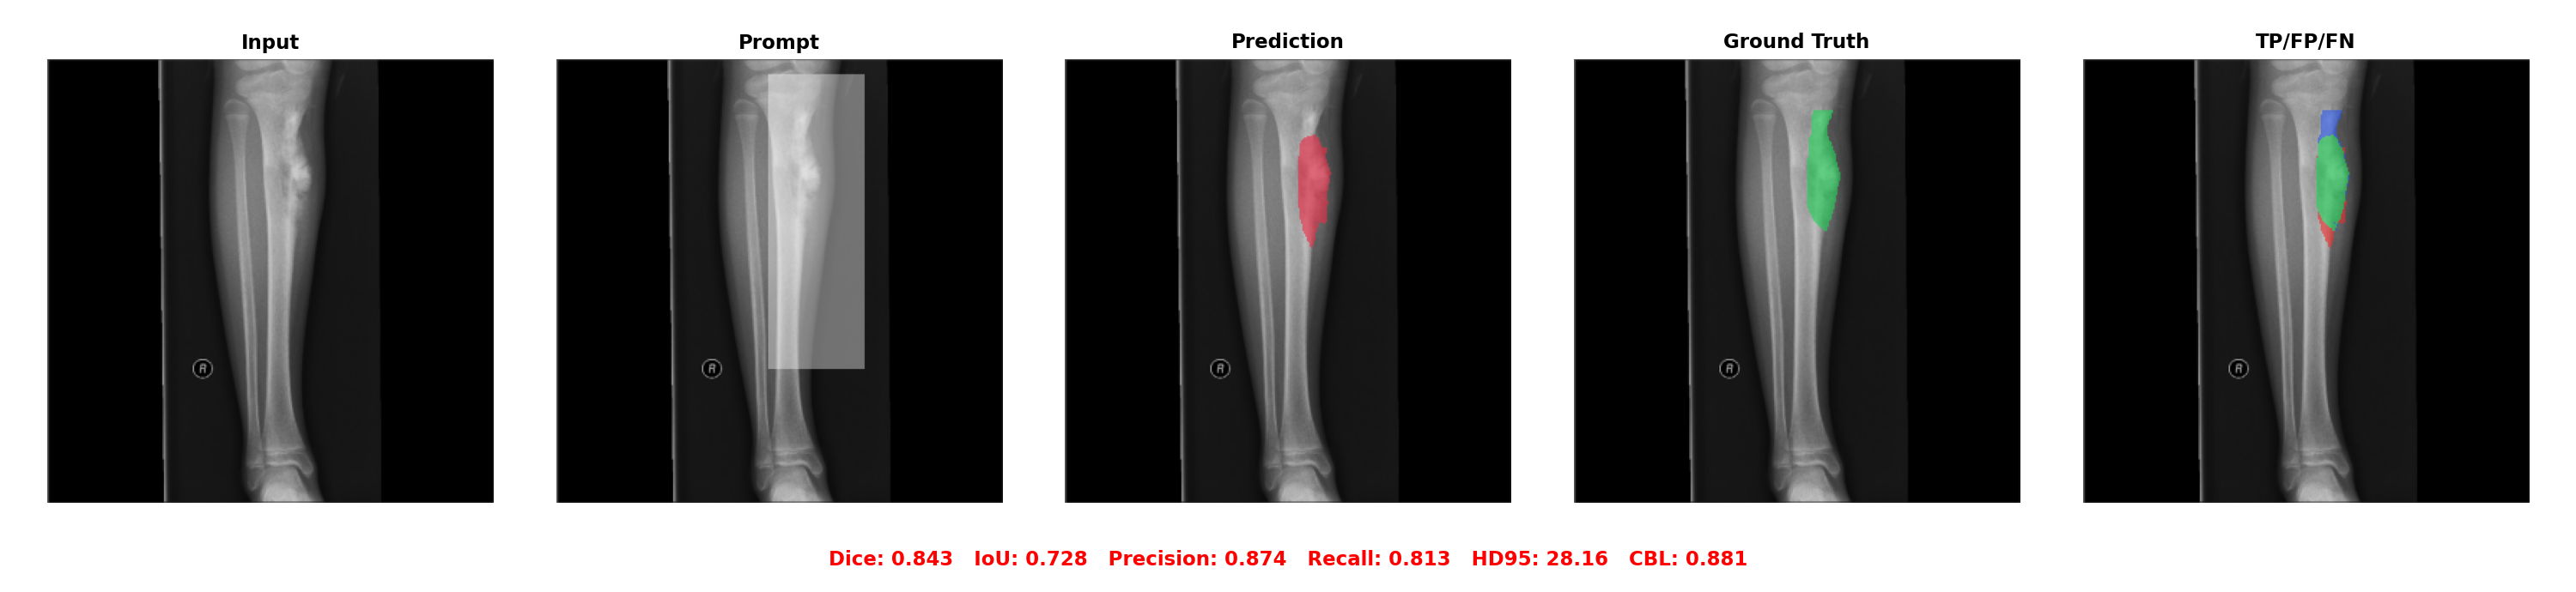

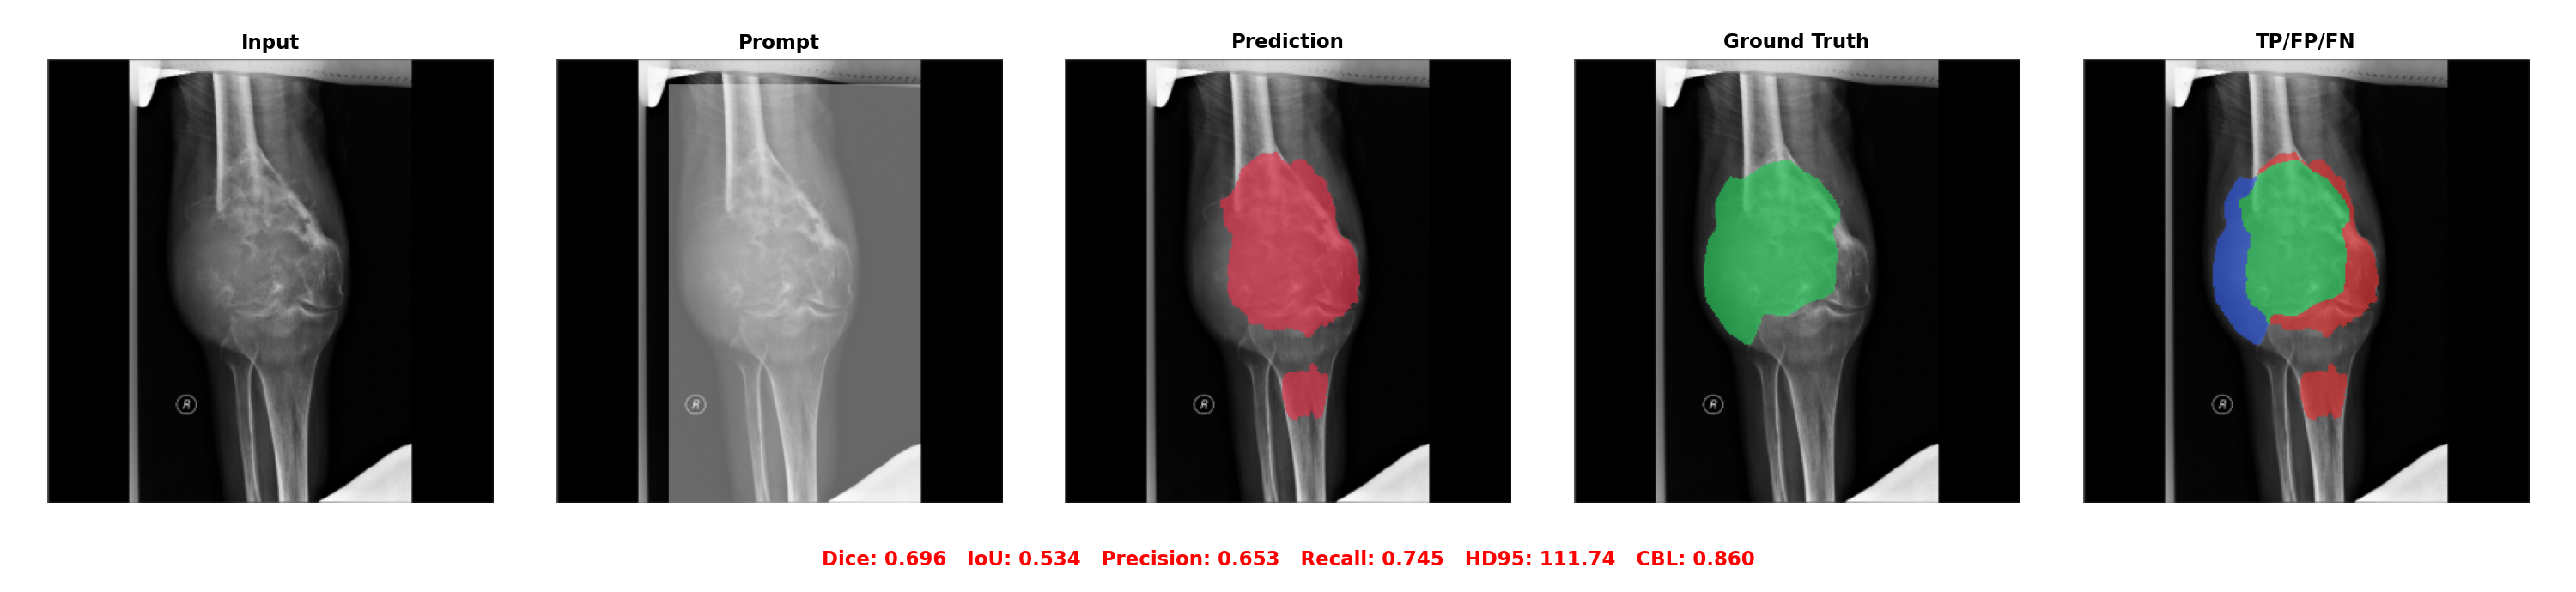

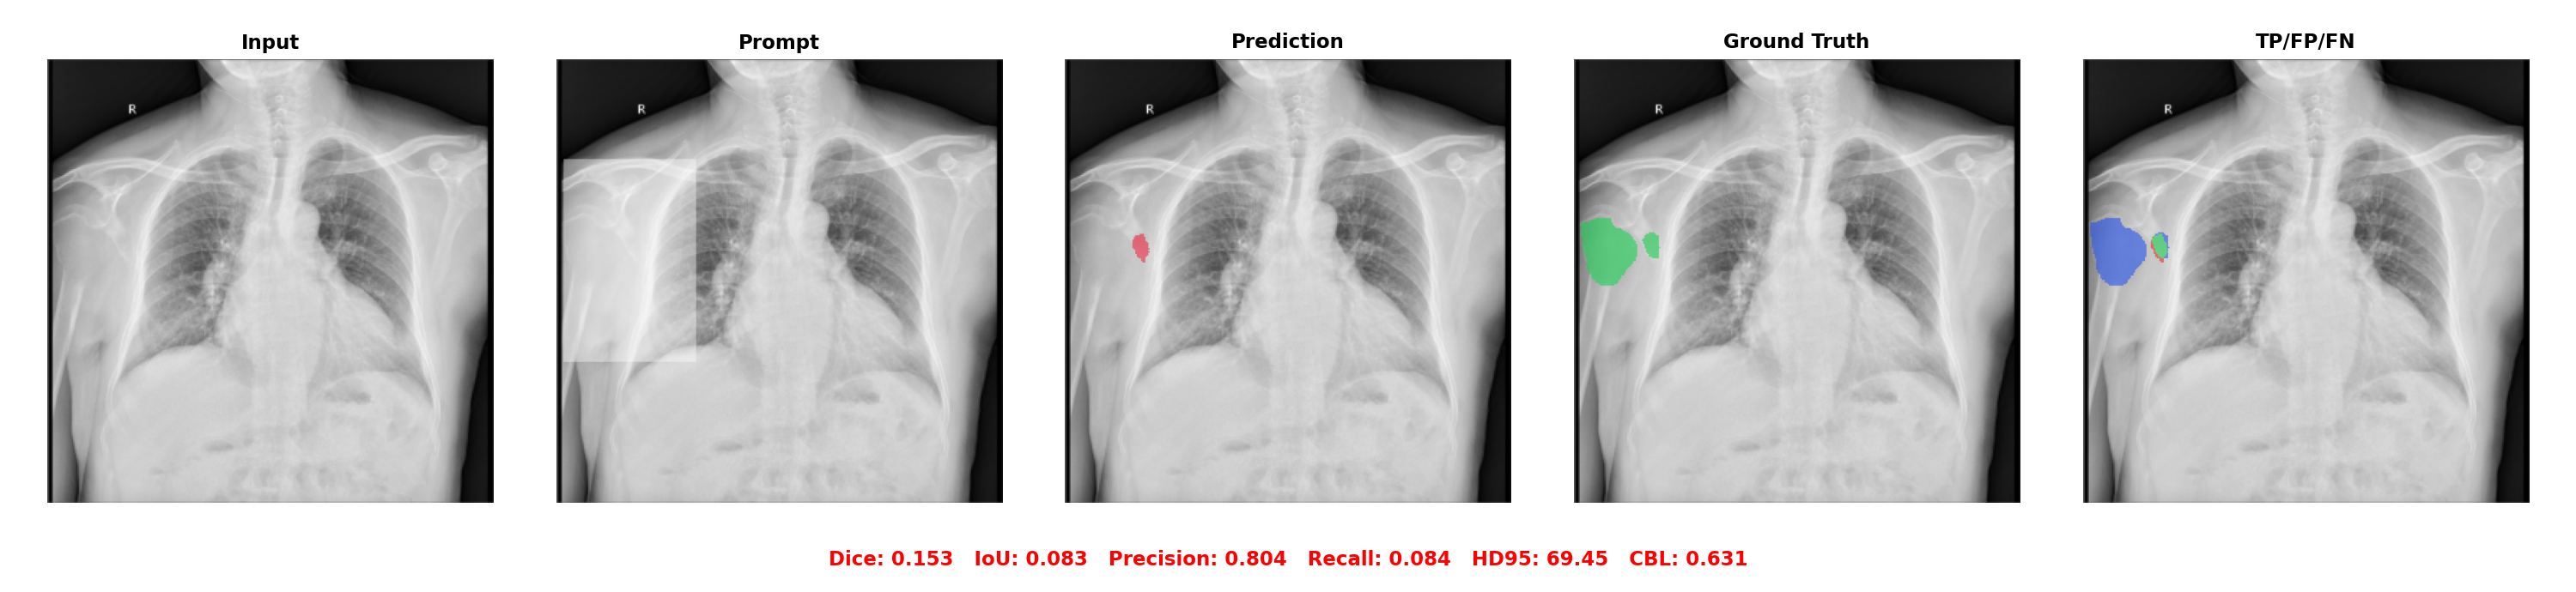

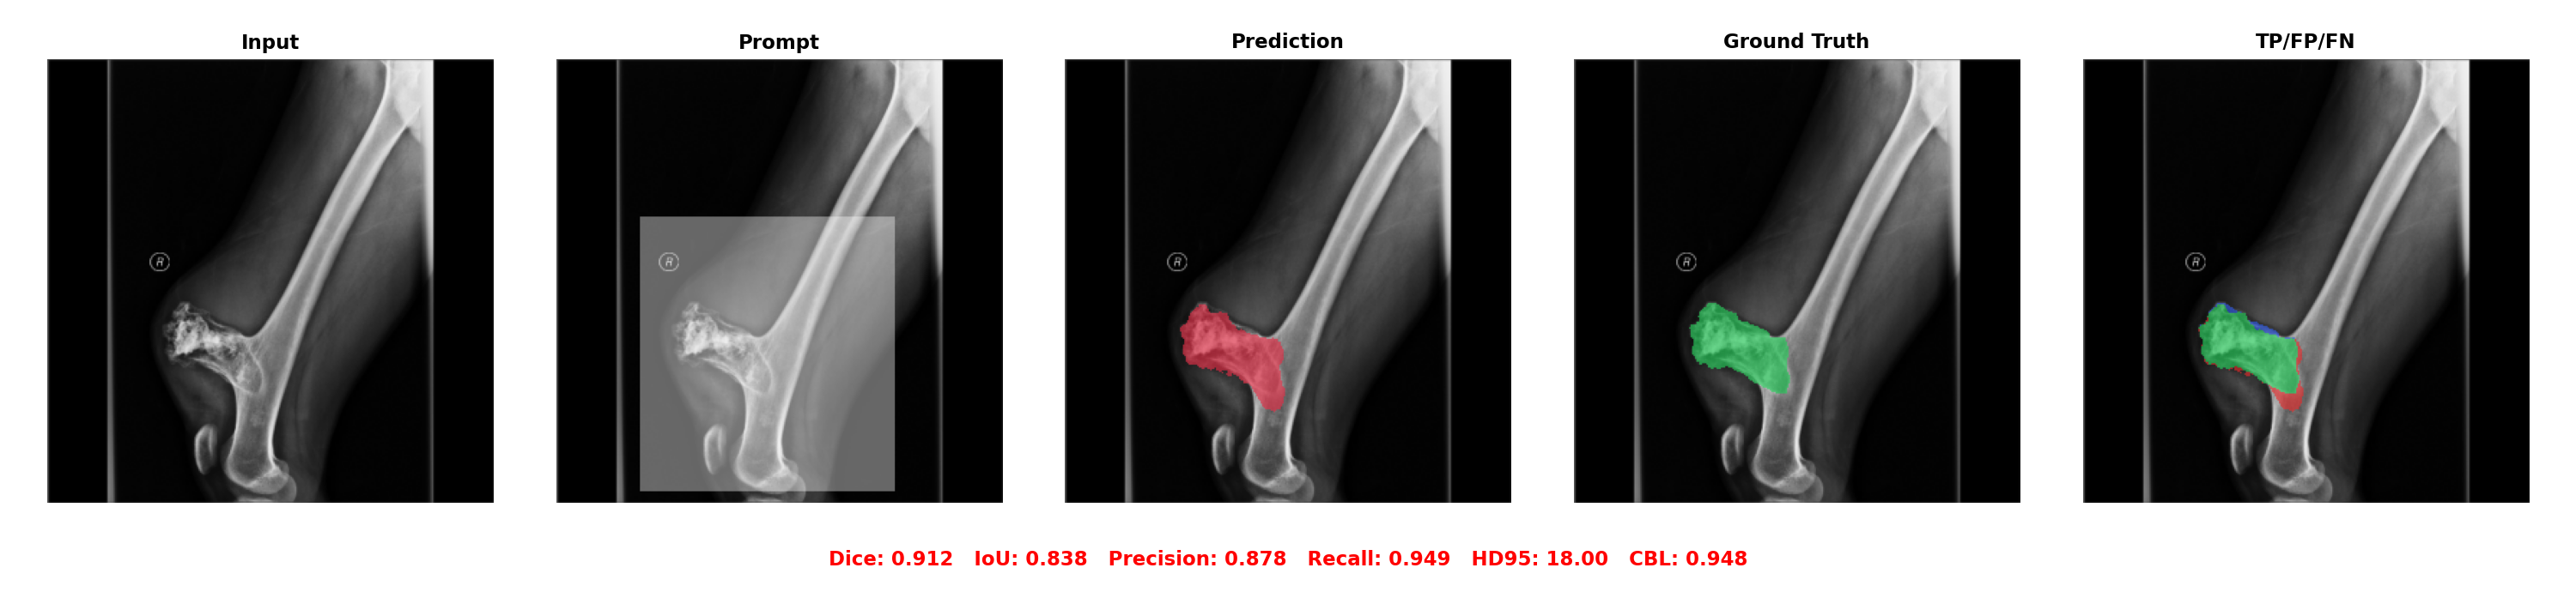

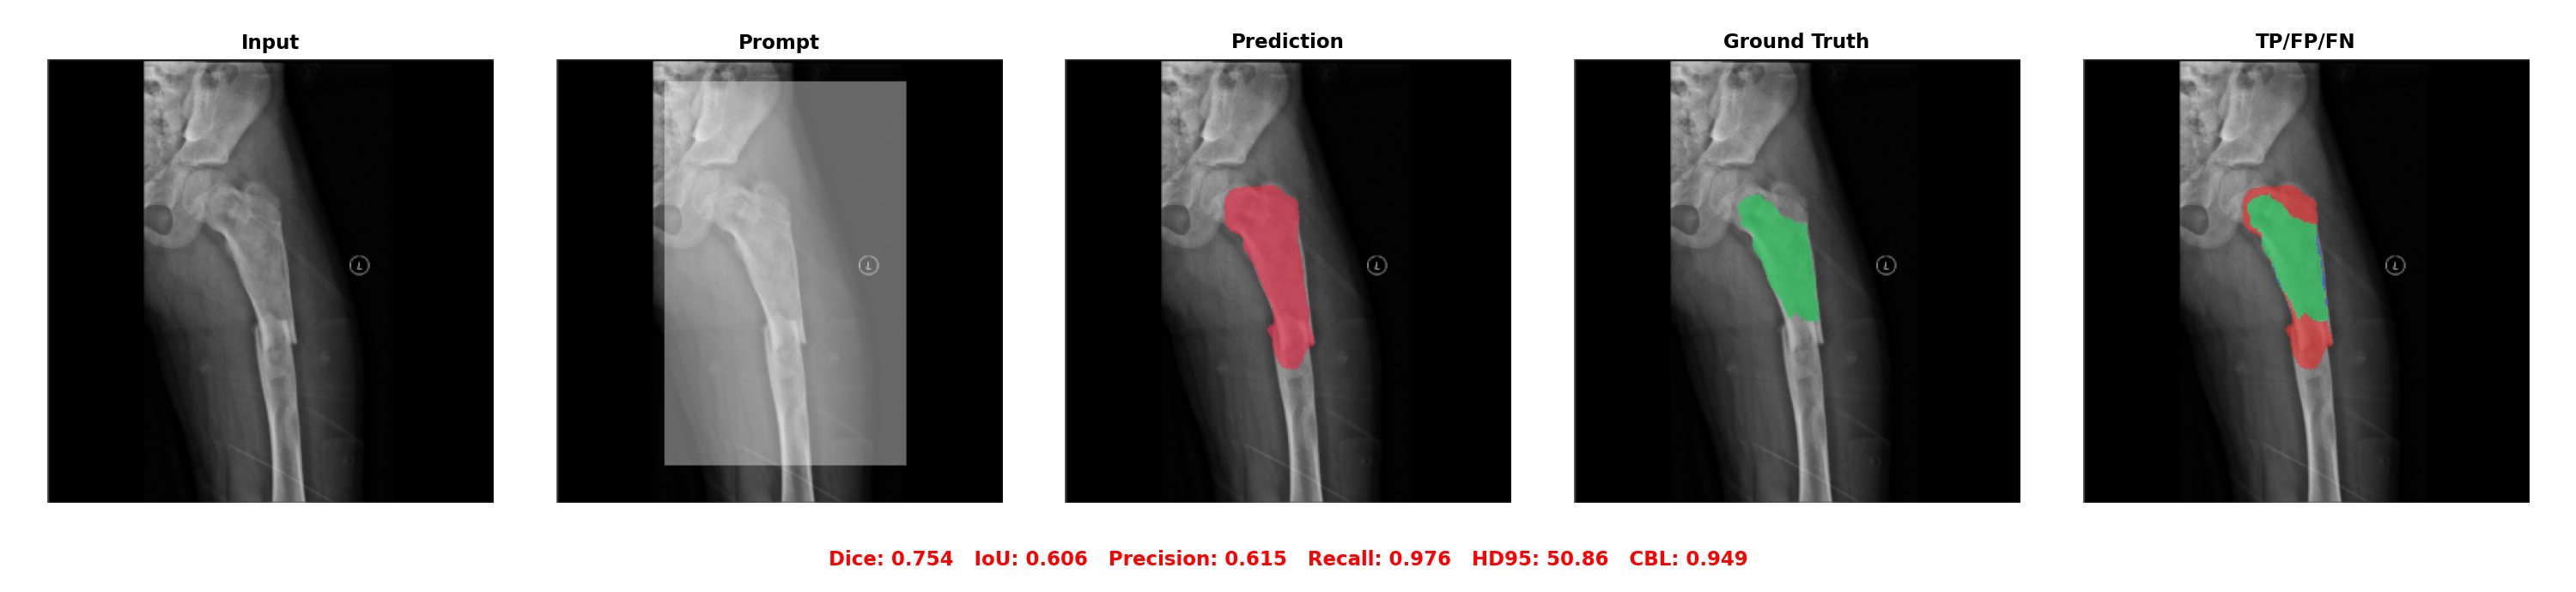

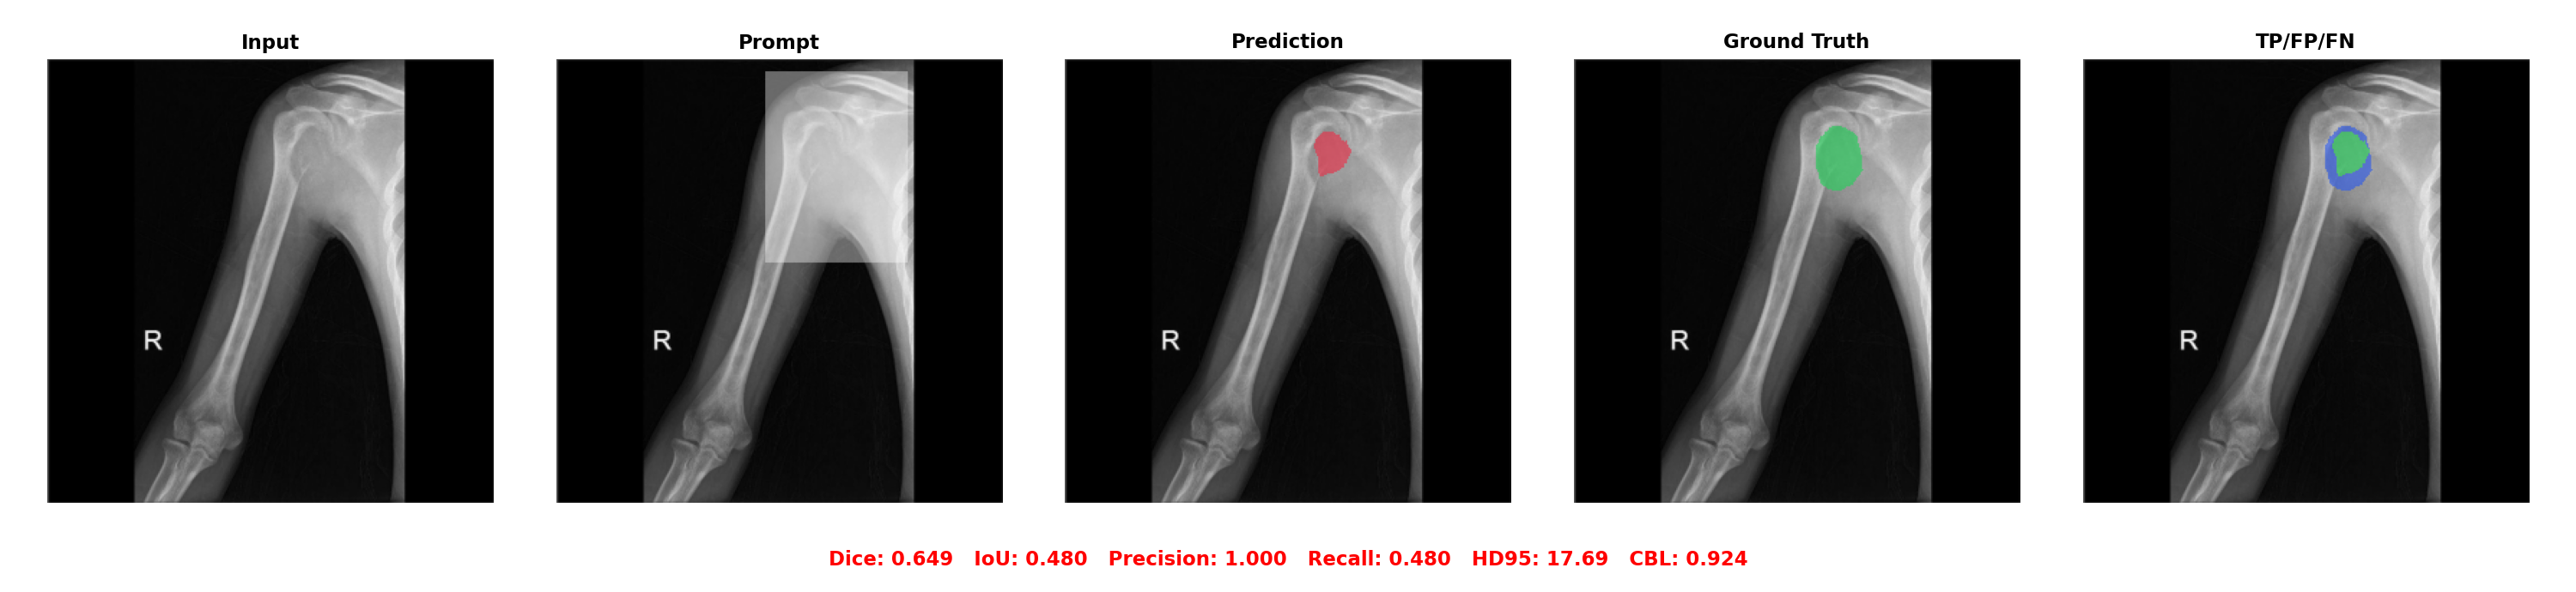

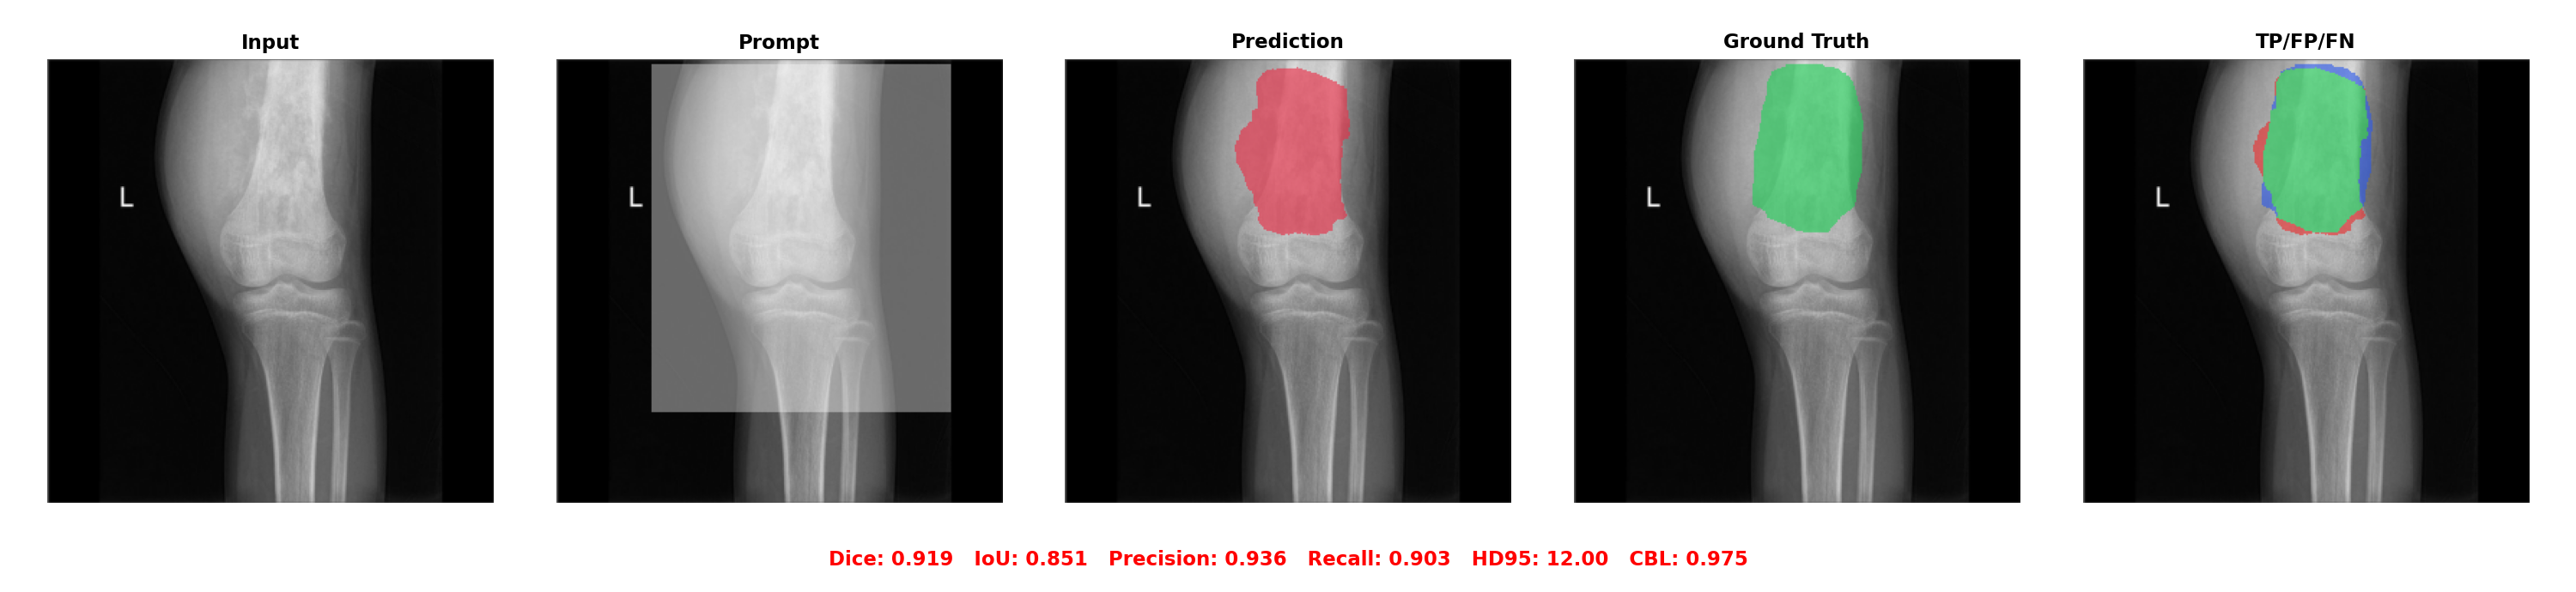

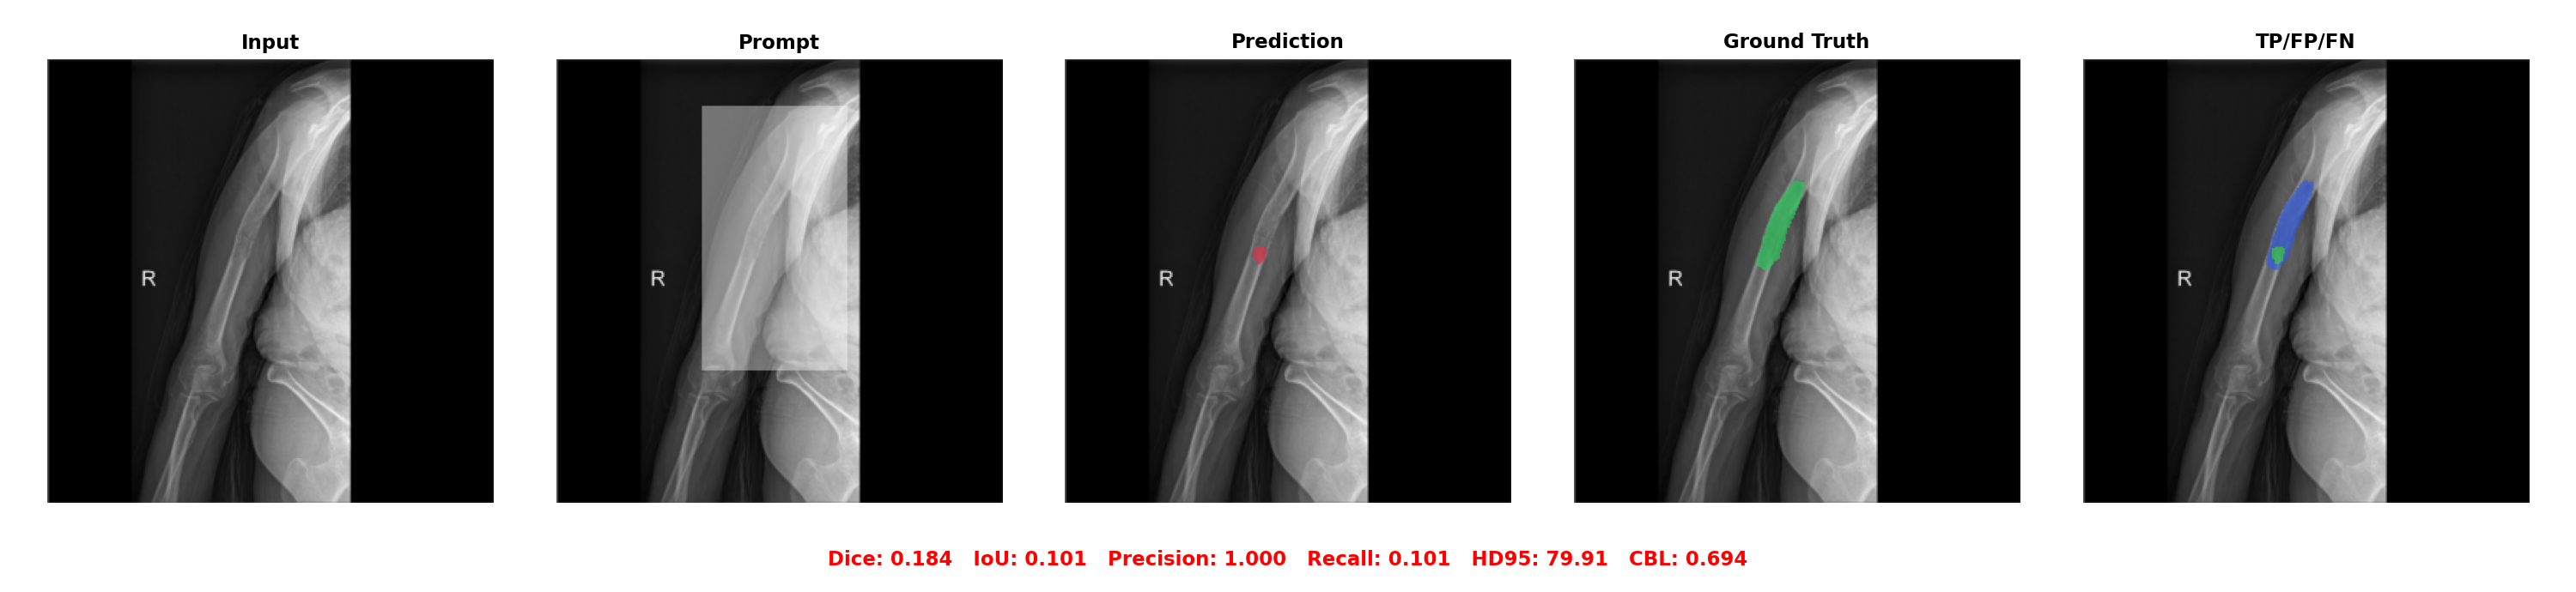

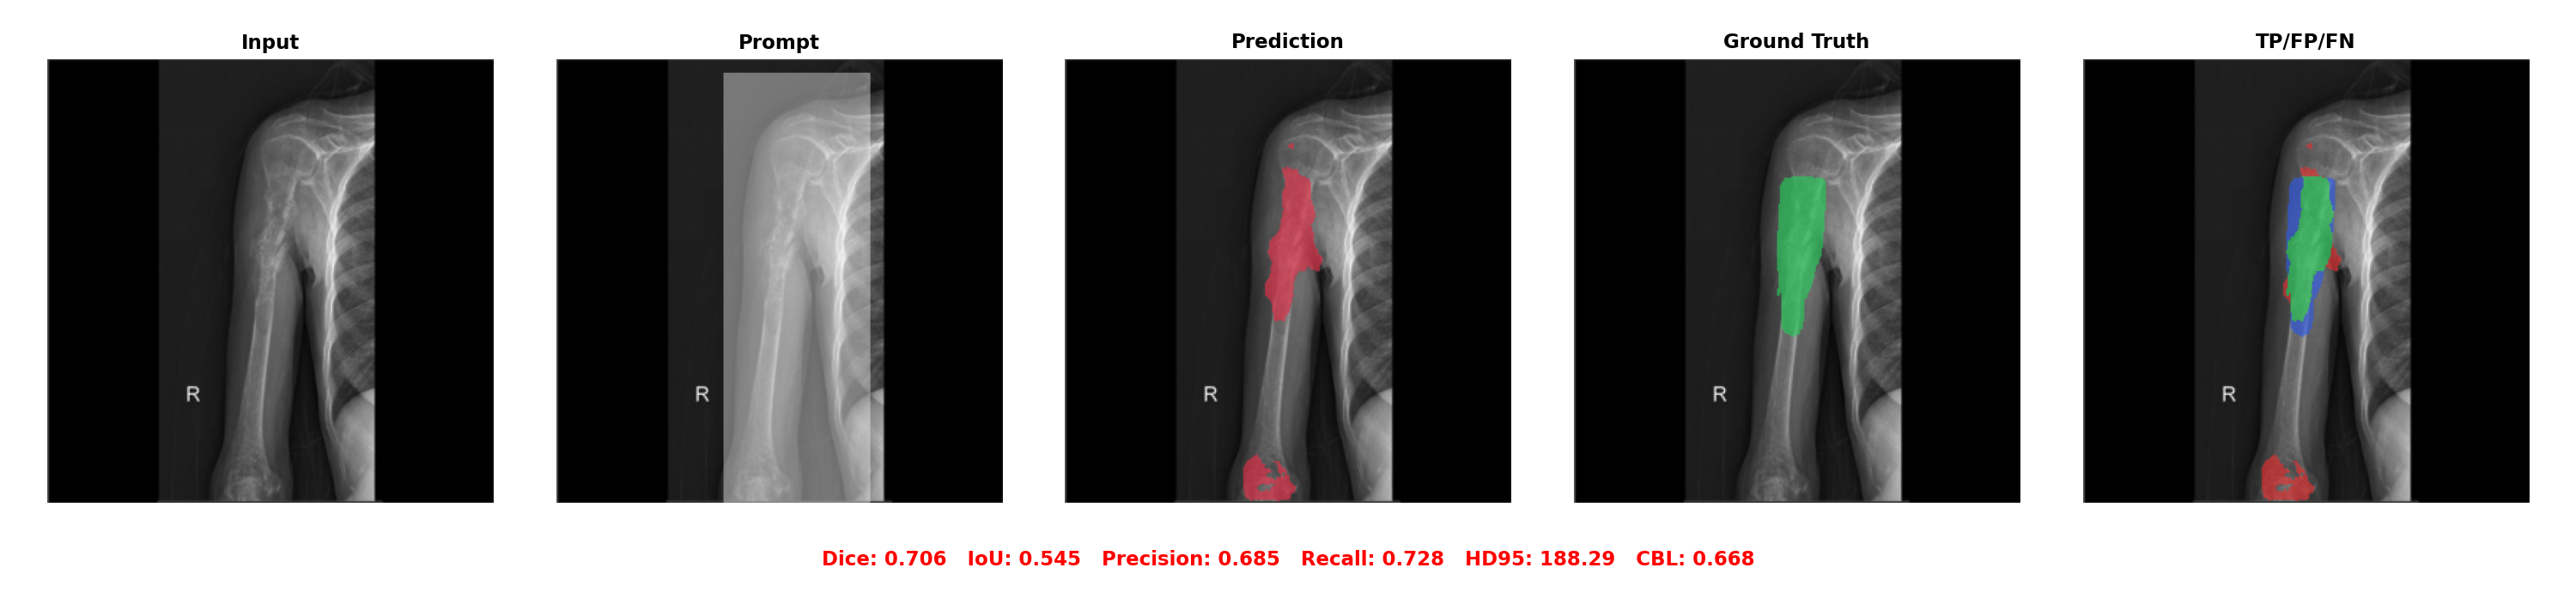

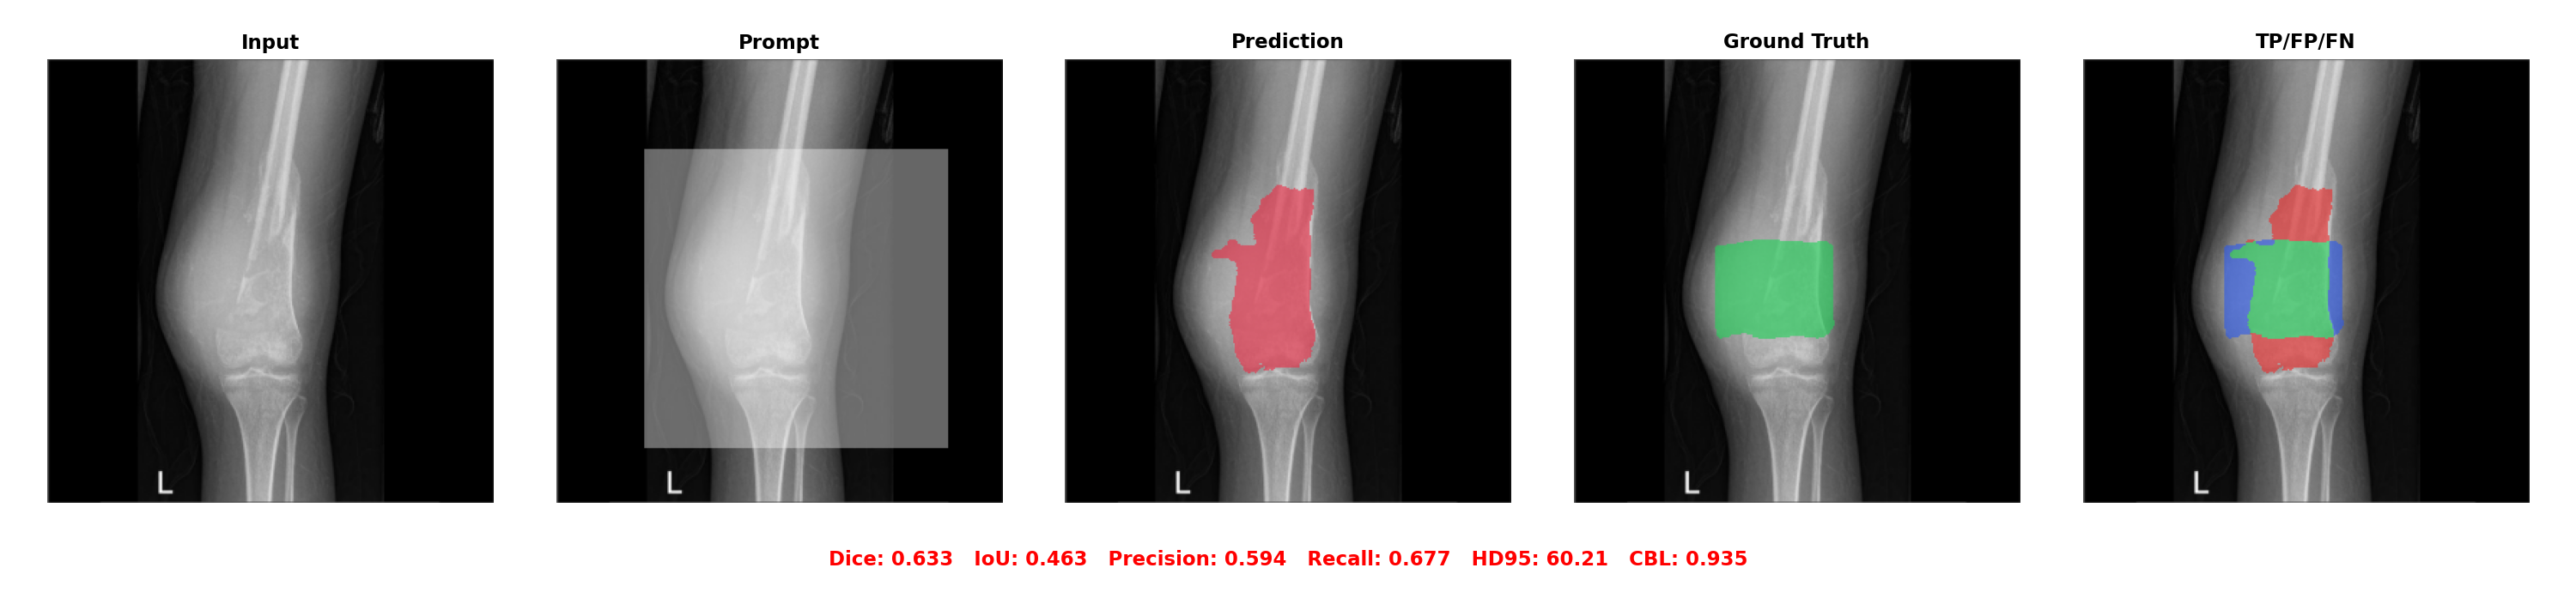

In [6]:
# ── File Test: Balanced qualitative visualization (center_shift, same stems as center_zoom) ──
assert 'TRAIN_SHARED_STEMS' in dir(), '❌ Run the center_zoom visualization cell first'
recs = records_for_stems(all_image_records['center_shift'], TRAIN_SHARED_STEMS, context='center_shift qualitative records')
N_SHOW = len(recs)

col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for count, rec in enumerate(recs):
    img_np = rec['img'] * 0.5 + 0.5
    gt_np = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0) if len(rec['prompts']) else np.zeros_like(gt_np)
    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1 - gt_np)).sum(); fn = ((1 - pred_np) * gt_np).sum(); eps = 1e-6
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec_ = (tp + eps) / (tp + fn + eps)

    fig, row = plt.subplots(1, 5, figsize=(20, 4.6), squeeze=False)
    row = row[0]
    fig.suptitle(f'{VARIANT_NAME} | center_shift | {rec["img_name"]}', fontsize=13, fontweight='bold', y=0.995)
    for panel_ax, column_title in zip(row, col_titles):
        panel_ax.set_title(column_title, fontsize=10, fontweight='bold')
    bg = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{rec["n_samples"]}p]\nDice={dice:.3f}', fontsize=8)
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged > 0, prompt_merged, np.nan), cmap='gray', alpha=0.40, vmin=0, vmax=1)
    row[2].imshow(bg); row[2].imshow(pred_np, cmap='Blues', alpha=0.60 * pred_np, vmin=0, vmax=1)
    row[3].imshow(bg); row[3].imshow(gt_np, cmap='Greens', alpha=0.60 * gt_np, vmin=0, vmax=1)
    overlay = np.zeros((*gt_np.shape, 3), dtype=float)
    overlay[..., 1] = pred_np * gt_np
    overlay[..., 0] = pred_np * (1 - gt_np)
    overlay[..., 2] = (1 - pred_np) * gt_np
    row[4].imshow(bg); row[4].imshow(overlay, alpha=0.75 * np.any(overlay > 0, axis=-1), vmin=0, vmax=1)
    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))
    plt.tight_layout(rect=[0, 0.13, 1, 0.94])
    export_qualitative_rows(
        fig, row[np.newaxis, :], [rec],
        prefix=f'{safe_name}_center_shift_{count + 1:02d}',
    )

